<a href="https://colab.research.google.com/github/dudals96/agents.md/blob/main/%5B%EC%88%98%EA%B0%95%EC%83%9D%EC%9A%A9%5D_3%EA%B8%B0_3%ED%9A%8C%EC%B0%A8_%EB%8F%99%EA%B7%B8%EB%9D%BC%EB%AF%B8%EC%9E%AC%EB%8B%A8_%EC%8B%AC%ED%99%94%EB%B0%98_%EC%8B%A4%EC%8A%B5%EA%B5%90%EC%9E%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ⚙️ 실습 전 프로젝트 Set Up

```
💡
colab은 session으로 관리가 됩니다.
일정 시간이 지날 동안 아무런 동작을 하지 않거나,
새로운 브라우저에서 접속한 경우 아래 라이브러리들을 다시 설치해야합니다.
실습 시 프롬프트의 결과가 나오지 않는다면 상단 페이지에서 라이브러리를 재설치해주세요.
```

### ⚙️ <font color='Darkorange'><b>[ 설정 ]</b></font> 실습 진행을 위한 라이브러리 다운로드

실습에 필요한 라이브러리를 설치합니다. 아래 블록을 실행해 설치를 완료하세요.

```
💡How To:
실행하고자 하는 블럭을 클릭한 다음 왼쪽의 실행버튼(▶️)을 클릭하거나, `shift + Enter` 단축키를 통해 실행합니다.
```

In [ ]:
# 1. uv 설치
!pip install uv

In [ ]:
!uv pip install httpx==0.28.1 requests==2.32.4 rich langchain langsmith langchain_community langchain-openai anthropic langchain-anthropic langchain-google-genai google-ai-generativelanguage==0.6.15 openmeteo_requests requests-cache retry-requests

### ⚙️ <font color='Darkorange'><b>[ 설정 ]</b></font> 기타 Colab 설정

아래 코드는 출력 내용을 자동 줄바꿈합니다. 실행 버튼을 꼭 눌러주세요.

In [ ]:
from IPython.display import HTML, display
from rich import print as rprint

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

### ⚙️ <font color='Darkorange'><b>[ 설정 ]</b></font> Colab에서 secret key를 불러오는 함수 실행하기

설정에 입력한 API KEY를 실제로 사용가능하도록 하는 함수도 실행해주세요.

In [ ]:
import sys
from google.colab import userdata

def load_openai_api_key() -> str:
    try:
        key = userdata.get("OPENAI_API_KEY")
    except userdata.SecretNotFoundError:
        raise RuntimeError(
            "Colab Secrets에 'OPENAI_API_KEY'가 등록되어 있지 않습니다.\n"
            "→ 좌측 🔑 아이콘에서 이름 'OPENAI_API_KEY'로 추가하세요."
        )
    except userdata.NotebookAccessError:
        raise RuntimeError(
            "이 노트북에 'OPENAI_API_KEY' 접근 권한이 꺼져 있습니다.\n"
            "→ 좌측 🔑 아이콘 → 해당 시크릿의 'Notebook access' 토글을 켜주세요."
        )
    except Exception as e:
        raise RuntimeError(f"Colab userdata 호출 실패: {type(e).__name__}: {e}")

    if key is None or not key.strip():
        raise RuntimeError("OPENAI_API_KEY 값이 비어 있습니다. Secrets에 등록된 값을 확인하세요.")

    key = key.strip()
    print(f"[OK] OPENAI_API_KEY 로드 완료 (length={len(key)})", file=sys.stderr)
    return key

In [ ]:
OPENAI_API_KEY = load_openai_api_key()

다음의 셀을 실행해서 colab에 api key를 잘 등록했는지 확인하는 함수를 실행하세요.

In [ ]:
import sys
from google.colab import userdata
from openai import OpenAI, AuthenticationError, APIError

def validate_openai_apikey(api_key : str = None):
    try:
        OpenAI(api_key=api_key).models.list()
        print(f"[OK] 유효한 키 (sk-{api_key[:15]}...{api_key[-5:]})", file=sys.stderr)
    except AuthenticationError:
        raise RuntimeError("OpenAI 키가 유효하지 않습니다 (401).")
    except APIError as e:
        raise RuntimeError(f"OpenAI API 오류: {e}")


In [ ]:
validate_openai_apikey(OPENAI_API_KEY)

다음, key를 출력해서 colab에 api key 를 잘 등록했는지 확인해주세요.

In [ ]:
rprint(OPENAI_API_KEY)

출력값이 등록한 OPENAI API KEY와 일치한다면 사전 준비가 모두 완료 되었습니다. <br>
지금부터 실습을 해 보겠습니다.
<br/>
<br/>

```
💡
브라우저를 새로 시작하거나 세션이 만료된 뒤 다시 시작할 때는
[ 설정 ] 섹션을 모두 다시 실행해주셔야 합니다.
```

### ⚙️ <font color='Darkorange'><b>[ 설정 ]</b></font> OpenAI 모델 호출 함수 정의

API 사용 방법을 더 자세히 확인하고 싶다면, 아래 링크에서 정보를 확인해주세요. OpenAI Docs Link


<사용 가능한 모델 목록>

gpt-3.5-turbo
gpt-4o-mini (default)
gpt-4.1-nano
gpt-4.1-mini

In [ ]:
from openai import OpenAI
from enum import Enum

openai_client = OpenAI(
    api_key=OPENAI_API_KEY
)

class OpenAIModel(Enum):
    GPT_35_TURBO = "gpt-3.5-turbo"
    GPT_4O_MINI = "gpt-4o-mini"
    GPT_41_NANO = "gpt-4.1-nano"
    GPT_41_MINI = "gpt-4.1-mini"


def openai_request(user_input: str,
                   system_prompt: str | None = None,
                   model: str = OpenAIModel.GPT_4O_MINI,
                   temperature: float = 0.5,
                   top_p: float = 1.0,
                   max_tokens: int = 1000):

    # -- set messages
    messages = []
    if system_prompt:
        messages.append(
            {
                "role": "system",
                "content": system_prompt
            }
        )
    if user_input:
        messages.append(
            {
                "role": "user",
                "content": user_input
            }
        )
    #
    completion = openai_client.chat.completions.create(
        model=model.value,
        messages=messages,
        temperature=temperature,
        top_p=top_p,
        max_tokens=max_tokens,
    )
    return completion.choices[0].message

In [ ]:
# -- Test

result = openai_request(
    system_prompt="You are a candid AI assistant. Answer in Japanese.",
    user_input="이름이 뭐예요?"
)


print(result)

## 0️⃣ **<font color="#FFA500">0. 실습문제</font>**: **Tool Calling 기초 (함수 만드는 3단계)**

**1. tools 스키마 정의**

LLM이 사용할 수 있는 함수와 그 스키마를 정의한다.

함수 이름, 설명, 인자를 JSON으로 적어둔다.

LLM은 이걸 읽고 언제 이 함수를 쓸지 판단한다.

In [ ]:
tools = [
   {
       "type": "function",
       "function": {
           "name": "get_weather",
           "description": "특정 도시의 현재 날씨를 조회한다. 사용자가 '날씨 어때?', '비 와?' 같은 질문을 할 때 호출.",
           "parameters": {
               "type": "object",
               "properties": {
                   "city": {
                       "type": "string",
                       "description": "도시 이름 (예: Seoul, Tokyo)"
                   },
                   "unit": {
                       "type": "string",
                       "enum": ["celsius", "fahrenheit"],
                       "description": "온도 단위. 기본값은 celsius."
                   }
               },
               "required": ["city"]
           }
       }
   }
]

**2. 함수를 코드 단계로 구현**

실제로 동작하는 파이썬 함수.
LLM이 매개변수를 준다고 가정하고, 사용하게 될 함수를 구현한다.

In [ ]:
import openmeteo_requests
import requests
import requests_cache
from retry_requests import retry

# 클라이언트 세팅은 모듈 로드 시 1회만
_cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
_retry_session = retry(_cache_session, retries=5, backoff_factor=0.2)
_openmeteo = openmeteo_requests.Client(session=_retry_session)


def get_weather(city: str, unit: str = "celsius"):
    # 1) 도시명 → 위경도 (geocoding은 일반 REST)
    geo = requests.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={"name": city, "count": 1, "language": "en", "format": "json"},
        timeout=10,
    ).json()

    results = geo.get("results")
    if not results:
        return {"error": f"city not found: {city}"}

    lat = results[0]["latitude"]
    lon = results[0]["longitude"]
    resolved_name = results[0]["name"]

    # 2) 현재 날씨 (공식 클라이언트 사용)
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m",
        "temperature_unit": "fahrenheit" if unit == "fahrenheit" else "celsius",
    }
    responses = _openmeteo.weather_api(
        "https://api.open-meteo.com/v1/forecast",
        params=params,
    )
    response = responses[0]

    current = response.Current()
    temp = current.Variables(0).Value()

    return {
        "city": resolved_name,
        "temperature": round(temp, 1),
        "unit": unit,
    }

**3. LLM 콜링 루프를 구현**

LLM과 함수를 연결하고 호출한다.
LLM은 어떤 함수를 부를지 고르기만 한다.

실행은 우리 코드가 하고, 결과를 다시 LLM에게 넘겨 최종 답변을 받는다.

In [ ]:
from openai import OpenAI
import json

openai_client = OpenAI(
    api_key=OPENAI_API_KEY
)

messages = [{"role": "user", "content": "서울 날씨 어때?"}]

# 1차 호출: 모델이 함수 호출을 "제안"
response = openai_client.chat.completions.create(
   model="gpt-4o",
   messages=messages,
   tools=tools
)
tool_call = response.choices[0].message.tool_calls[0]
# 모델이 제안한 함수명과 인자 추출
if tool_call.function.name == "get_weather":
   args = json.loads(tool_call.function.arguments)
   result = get_weather(**args) # 실제 함수 실행

   # 2차 호출: 결과를 모델에 전달
   messages.append(response.choices[0].message)
   messages.append({
       "role": "tool",
       "tool_call_id": tool_call.id,
       "content": json.dumps(result)
   })

   final = openai_client.chat.completions.create(
       model="gpt-4o",
       messages=messages,
       tools=tools
   )
   print(final.choices[0].message.content)
   # → "서울은 현재 ... 도입니다."

## <font color='green'><b> ⚡ </b></font> 고급 기법:  ReAct Prompting, Tree-of-Thought, Self-reflection, Graph-of-Thought Prompting

## 1️⃣ <font color="#FFA500">**1. 실습문제**</font>: **ReAct Prompting**

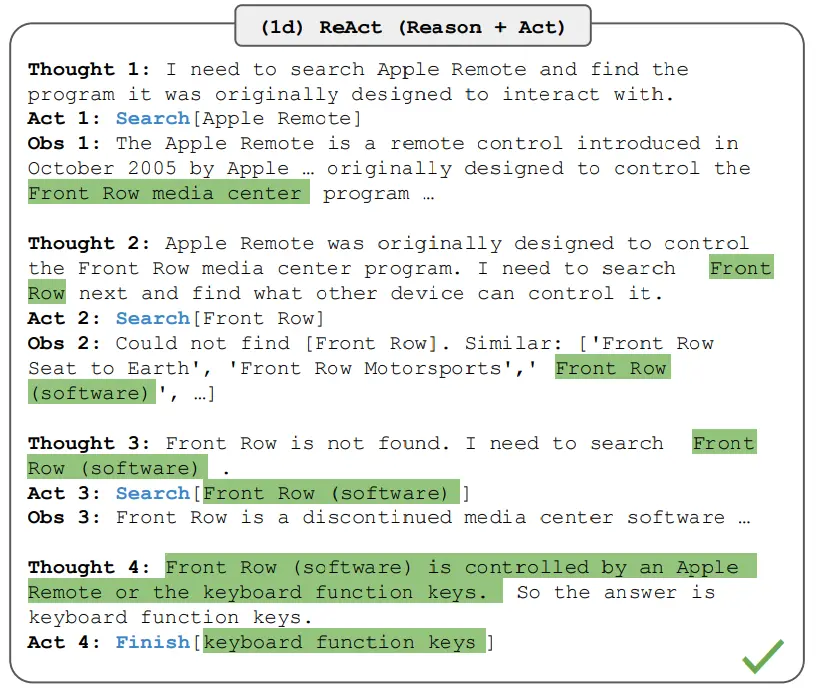


🔗 Image Source: Yao et al., 2022

##### 🔄 ReAct 실습 실행 흐름 #####
```
사용자 질문
  ↓
LLM이 Thought (생각)
  ↓
Action (도구 선택) + Action Input (입력값)
  ↓
Tool 실행 → Observation (결과)
  ↓
LLM이 결과 분석 → 반복 or Final Answer
  ↓
최종 답변

In [ ]:
from google.colab import userdata
import openai

# Colab Secrets에서 API 키 가져오기
api_key = load_openai_api_key()

# OpenAI 클라이언트 초기화
client = openai.OpenAI(api_key=api_key)

# 또는 환경변수로 설정
import os
os.environ['OPENAI_API_KEY'] = api_key

##### 🧪 ReAct 실습 프롬프트 작성

In [ ]:
# React Prompting 기반 시스템 프롬프트 작성해보기
# system_prompt =
# """Answer the following questions as best you can.
# You have access to the following tools:

# {tools}

# Use the following format:

# - Question: the input question you must answer
# - Thought: you should always think about what to do
# - Action: the action to take, should be one of [{tool_names}]
# - Action Input: the input to the action
# - Observation: the result of the action
# ... (this Thought/Action/Action Input/Observation can repeat N times)
# Thought: I now know the final answer
# Final Answer: the final answer to the original input question

# Begin!

# Question: {input}
# Thought:{agent_scratchpad}"""

###***
# ============================================
# Prompts - 이곳의 프롬프트를 편집하시오.
# ============================================

system_prompt ="""
            ..............................
            ....Write your prompt here....
            ..............................
"""
###***

##### 🛠️ 실습 에이전트 툴 정의

In [ ]:
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from geopy.geocoders import Nominatim
from datetime import datetime
from zoneinfo import ZoneInfo
import requests
from datetime import datetime, timedelta
import pytz
import json
import re
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor, create_react_agent #React 에이전트 생성 & 에이전트 실행기 Prebuilt
from langchain_core.prompts import PromptTemplate

geolocator = Nominatim(user_agent="weather-agent")

In [ ]:
# ============================================
# 공통 입력값 정리 함수
# ============================================
def clean_input(value: str) -> str:
    """
    LangChain ReAct 에이전트가 넘기는 입력값에서
    불필요한 문자를 모두 제거합니다.

    문제 원인:
    - ReAct 에이전트의 output parser가 Action Input을 추출할 때
      뒤에 개행문자(\n), 공백, 따옴표 등이 붙는 경우가 많음
    - 예: 'Asia/Seoul  \n' → pytz가 인식 못함
    - 예: '"Tokyo"' → geopy가 인식 못함
    """
    if not isinstance(value, str):
        return value
    # 1단계: 앞뒤 공백, 개행, 탭, 캐리지리턴 모두 제거
    value = value.strip()
    # 2단계: 앞뒤 따옴표 제거 (작은따옴표, 큰따옴표)
    value = value.strip("'\"")
    # 3단계: 다시 한번 공백 제거 (따옴표 안에 공백이 있을 수 있음)
    value = value.strip()
    # 4단계: 내부의 제어문자 제거 (\n, \r, \t 등)
    value = re.sub(r'[\n\r\t]', '', value)
    return value


# ============================================
# Tool 1: 현재 시간 조회
# ============================================
@tool("get_current_time", return_direct=False)
def get_current_time(timezone: str = "UTC") -> str:
    """
    지정된 타임존의 현재 시간을 반환합니다.

    Args:
        timezone: 타임존 문자열 (예: 'UTC', 'Asia/Seoul', 'Asia/Tokyo', 'America/New_York')

    Returns:
        현재 날짜와 시간 (YYYY-MM-DD HH:MM:SS 형식)
    """
    try:
        timezone = clean_input(timezone)  # ★ 수정

        tz = pytz.timezone(timezone)
        current_time = datetime.now(tz)
        return current_time.strftime("%Y-%m-%d %H:%M:%S %Z")
    except pytz.exceptions.UnknownTimeZoneError:
        return f"오류: 알 수 없는 타임존 '{timezone}'. 'UTC', 'Asia/Seoul', 'Asia/Tokyo' 등을 사용하세요."
    except Exception as e:
        return f"오류: {str(e)}"


# ============================================
# Tool 2: 내일 날짜 계산
# ============================================
@tool("get_tomorrow_date", return_direct=False)
def get_tomorrow_date(timezone: str = "Asia/Seoul") -> str:
    """
    지정된 타임존의 내일 날짜를 YYYY-MM-DD 형식으로 반환합니다.

    Args:
        timezone: 타임존 문자열 (기본값: 'Asia/Seoul')

    Returns:
        내일 날짜 (YYYY-MM-DD 형식)
    """
    try:
        timezone = clean_input(timezone)  # ★ 수정

        tz = pytz.timezone(timezone)
        tomorrow = datetime.now(tz) + timedelta(days=1)
        return tomorrow.strftime("%Y-%m-%d")
    except pytz.exceptions.UnknownTimeZoneError:
        return f"오류: 알 수 없는 타임존 '{timezone}'. 'UTC', 'Asia/Seoul', 'Asia/Tokyo' 등을 사용하세요."
    except Exception as e:
        return f"오류: {str(e)}"


# ============================================
# Tool 3: 날씨 예보 조회
# ============================================
class SearchInput(BaseModel):
    """날씨 조회 입력 스키마"""
    location: str = Field(description="도시명 (예: Berlin, Seoul, Tokyo)")
    date: str = Field(
        description="예보 날짜 (yyyy-mm-dd 형식). 기본값은 오늘 날짜",
        default=datetime.today().strftime("%Y-%m-%d")
    )

@tool("get_weather_forecast", args_schema=SearchInput, return_direct=False)
def get_weather_forecast(location: str, date: str = None) -> str:
    """특정 위치와 날짜의 날씨를 Open-Meteo API를 사용하여 조회합니다.
    시간별 온도 데이터를 딕셔너리 형태로 반환합니다."""

    # ★ 수정: 입력값 정리
    location = clean_input(location)

    # ★ 수정: location에 JSON 문자열이 통째로 들어오는 경우 처리
    if location.startswith("{"):
        try:
            parsed = json.loads(location)
            location = clean_input(parsed.get("location", location))
            if "date" in parsed:
                date = clean_input(parsed["date"])
        except json.JSONDecodeError:
            pass

    # date 처리
    if date is None or date == "":
        date = datetime.today().strftime("%Y-%m-%d")
    else:
        date = clean_input(date)

    # Geopy로 위치 검색
    location_obj = geolocator.geocode(location)
    if location_obj:
        try:
            response = requests.get(
                f"https://api.open-meteo.com/v1/forecast?"
                f"latitude={location_obj.latitude}&"
                f"longitude={location_obj.longitude}&"
                f"hourly=temperature_2m&"
                f"start_date={date}&end_date={date}"
            )
            data = response.json()

            if "hourly" not in data:
                return f"오류: {date} 날짜의 날씨 데이터를 가져올 수 없습니다. 응답: {data}"

            weather_data = {
                time: temp
                for time, temp in zip(
                    data["hourly"]["time"],
                    data["hourly"]["temperature_2m"]
                )
            }

            sample = dict(list(weather_data.items())[:3])
            return f"{location} on {date}: {sample} (총 {len(weather_data)}개 시간 데이터)"

        except Exception as e:
            return f"오류: {str(e)}"
    else:
        return f"오류: '{location}' 위치를 찾을 수 없습니다. 영문 도시명을 사용하세요 (예: Tokyo, Seoul)"


# ============================================
# 도구 목록
# ============================================
tools = [get_current_time, get_tomorrow_date, get_weather_forecast]

print("\n✅ 도구 정의 완료!")
print(f"사용 가능한 도구: {[tool.name for tool in tools]}")

##### 🤖 실습 에이전트 동작 및 테스트

In [ ]:

# ============================================
# ReAct 에이전트 생성
# ============================================
print("=" * 80)
print("🤖 ReAct 날씨 에이전트 생성 중...")
print("=" * 80)

system_prompt = """
사용자 질문에 기반하여 정보를 제공하세요.
정확한 정보 제공을 위해 아래 제공된 도구를 사용하세요.

사용 가능한 도구:
{tools}

도구 이름: {tool_names}

중요한 사용 규칙:
1. get_current_time: 현재 시간 조회
   - Action Input: Asia/Seoul (따옴표 없이)

2. get_tomorrow_date: 내일 날짜 계산 (YYYY-MM-DD 형식 반환)
   - Action Input: Asia/Tokyo (따옴표 없이)
   - 사용자가 "내일"이라고 하면 이 도구를 먼저 호출

3. get_weather_forecast: 날씨 조회 (JSON 형식 필수)
   - Action Input: {{"location": "Tokyo", "date": "2026-02-20"}}
   - 오늘 날씨는 date 생략: {{"location": "Seoul"}}

**"내일 날씨" 질문 처리 순서:**
Step 1: get_tomorrow_date로 내일 날짜 얻기 (예: Asia/Tokyo)
Step 2: 얻은 날짜로 get_weather_forecast 호출 {{"location": "Tokyo", "date": "2026-02-20"}}

같은 오류가 2번 반복되면 접근 방법을 바꾸세요.

대한민국 서울 기준의 현재 일자와 시간이 필요한 경우, 다음의 일자를 사용하세요. {date_now}

다음 형식을 사용하세요:
Question: 답변해야 할 입력 질문
Thought: 무엇을 해야 할지 항상 생각해야 합니다
Action: 수행할 작업, [{tool_names}] 중 하나여야 합니다
Action Input: 작업에 대한 입력
Observation: 작업의 결과
... (이 Thought/Action/Action Input/Observation은 N번 반복될 수 있습니다)
Thought: 이제 최종 답변을 알았습니다
Final Answer: 원래 입력 질문에 대한 최종 답변

시작하세요!

Question: {input}
Thought: {agent_scratchpad}"""

prompt = PromptTemplate.from_template(system_prompt).partial(
    date_now=datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y-%m-%d")
)

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

agent = create_react_agent(llm, tools, prompt)

# ★ 수정: early_stopping_method="force"
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors="Action Input 형식이 잘못되었습니다. JSON 형식을 사용하세요: {\"location\": \"Tokyo\", \"date\": \"2026-02-20\"}",
    max_iterations=10,
    max_execution_time=60,
    early_stopping_method="force",  # ★ "generate" → "force"
)

print("✅ 에이전트 생성 완료!\n")

# ============================================
# 안전한 에이전트 실행 함수
# ============================================
def run_agent_safe(query: str) -> str:
    """오류 처리가 강화된 에이전트 실행 함수"""
    try:
        result = agent_executor.invoke({"input": query})
        return result.get('output', '답변을 생성할 수 없습니다.')
    except Exception as e:
        error_msg = str(e)
        if "iteration limit" in error_msg.lower() or "time limit" in error_msg.lower():
            return "죄송합니다. 요청 처리 시간이 초과되었습니다. 질문을 더 단순하게 바꿔주시겠어요?"
        elif "parsing" in error_msg.lower():
            return "답변 형식 처리 중 오류가 발생했습니다. 다시 시도해주세요."
        else:
            return f"오류가 발생했습니다: {error_msg}"

In [ ]:
# ============================================
# 테스트 1: 현재 시간 확인
# ============================================
print("=" * 80)
print("테스트 1️⃣: 현재 시간 확인 (Asia/Seoul)")
print("=" * 80)

query = "지금 도쿄 시간이 몇 시야?"
print(f"\n>>> 질문: {query}\n")
print("🔄 에이전트 실행 중...\n")
result_output = run_agent_safe(query)
print(f"\n✅ 최종 답변: {result_output}\n")

print("=" * 80)
print(" 테스트 1 완료!")
print("=" * 80)

# ============================================
# 테스트 2: 날씨 조회
# ============================================
print("\n" + "=" * 80)
print("테스트 2️⃣: 서울 날씨 조회")
print("=" * 80)

query = "서울의 4/18일 날씨는 어때?"
print(f"\n>>> 질문: {query}\n")
print("🔄 에이전트 실행 중...\n")
result_output = run_agent_safe(query)
print(f"\n✅ 최종 답변: {result_output}\n")

print("=" * 80)
print(" 테스트 2 완료!")
print("=" * 80)

# ============================================
# 테스트 3: 내일 이탈리아 밀라노 날씨 조회
# ============================================
print("\n" + "=" * 80)
print("테스트 3️⃣: 내일 캐나다 벤쿠버 날씨 조회")
print("=" * 80)

query = "내일 이탈리아 밀라노 날씨는 어떨까?"
print(f"\n📝 질문: {query}\n")
print("🔄 에이전트 실행 중...\n")
result_output = run_agent_safe(query)
print(f"\n✅ 최종 답변: {result_output}\n")

print("=" * 80)
print(" 테스트 3 완료!")
print("=" * 80)

## 2️⃣ <font color="#FFA500">**2. 실습문제**</font>: **Self-reflection Prompting**

> Self-reflection prompting 을 학습해보겠습니다.
이 프롬프트 기법은 한 번에 정답을 생성하지 않고, 모델 자신의 출력물을 검증하는 과정을 거칩니다.

1. 모델이 초안(initial draft)을 생성
2. 1번의 초안을 다시 입력하여 자기 평가(self-evaluation) 수행
3. 오류를 수정하고 개선된 답변(revised answer)을 생성


이 기법에 대한 실증적인 연구들의 결론은, 모델의 추론성능을 보편적으로 올렸지만 작업 종류와 오류 종류에 따라 성능이 달라진다입니다.

🔗 참고 논문: https://arxiv.org/pdf/2405.06682

<hr>

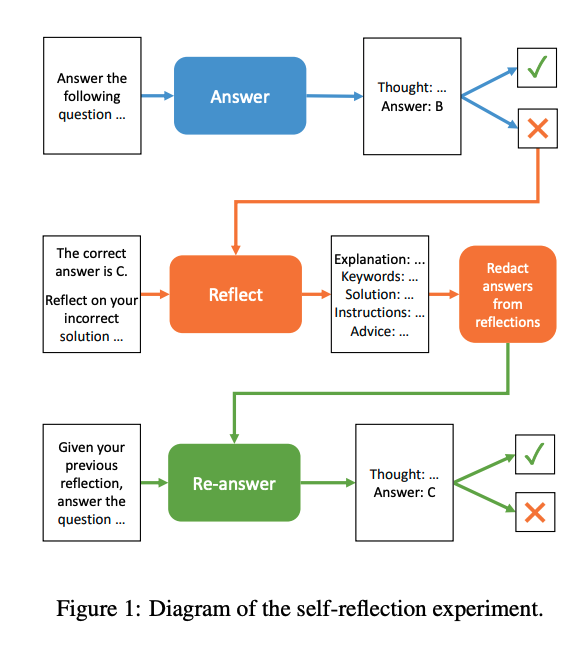

self-reflection 활용 실습 예제알아봅시다.



---



**Generate**

이번 실습에서는 **LinkedIn 게시글을 생성**하는 generator를 만듭니다.  
생성된 게시글은 `Self-Reflection` 과정을 거쳐 자동으로 개선됩니다.

먼저, generator를 생성합니다.

### ⚙️ **[ 실습 전 ] Self-reflection Prompting 실습 환경 설정**

**1. API key 세팅**

In [ ]:
import sys
from google.colab import userdata

def load_openai_api_key() -> str:
    try:
        key = userdata.get("OPENAI_API_KEY")
    except userdata.SecretNotFoundError:
        raise RuntimeError(
            "Colab Secrets에 'OPENAI_API_KEY'가 등록되어 있지 않습니다.\n"
            "→ 좌측 🔑 아이콘에서 이름 'OPENAI_API_KEY'로 추가하세요."
        )
    except userdata.NotebookAccessError:
        raise RuntimeError(
            "이 노트북에 'OPENAI_API_KEY' 접근 권한이 꺼져 있습니다.\n"
            "→ 좌측 🔑 아이콘 → 해당 시크릿의 'Notebook access' 토글을 켜주세요."
        )
    except Exception as e:
        raise RuntimeError(f"Colab userdata 호출 실패: {type(e).__name__}: {e}")

    if key is None or not key.strip():
        raise RuntimeError("OPENAI_API_KEY 값이 비어 있습니다. Secrets에 등록된 값을 확인하세요.")

    key = key.strip()
    print(f"[OK] OPENAI_API_KEY 로드 완료 (length={len(key)})", file=sys.stderr)
    return key

In [ ]:
openai_api_key = load_openai_api_key()

# 환경변수 반영
os.environ.update(
    {
        "OPENAI_API_KEY": OPENAI_API_KEY,
    }
)

print("✅ API KEY 설정 완료")

**2. 최소 필수 패키지 설치**

In [ ]:
!pip install uv

In [ ]:
!uv pip uninstall -y openai langchain-openai langchain-core langchain httpx
!uv pip install -U langchain-core langchain-openai

### 📝 **[ 실습 ] 링크드인 게시글 생성기 실습 (Self-reflection Prompting 활용)**

**1. 링크드인 게시글 생성 체인 실행**

In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI

system_prompt = (
    "system",
    "You are an expert LinkedIn Korean content creator tasked with crafting compelling, professional, and high-performing LinkedIn posts. "
    "Create the most effective LinkedIn post possible based on my requirements. "
    "If I provide feedback or suggestions, respond with an improved version that incorporates their input while enhancing overall quality and engagement. "
    "Language: Korean"
)

post_creation_prompt = ChatPromptTemplate.from_messages(
    [
        system_prompt,
        MessagesPlaceholder(variable_name="messages"),
    ]
)

llm = ChatOpenAI(model="gpt-4o-mini")
linkedin_post_generator = post_creation_prompt | llm

print("✔️ 링크드인 게시글 생성 체인이 로드되었습니다!")

In [ ]:
from langchain_core.messages import HumanMessage

generated_post = ""

post_request = HumanMessage(
    content="""
    -주제: React Prompting 기법과 Graph-of Prompting 기법의 차이점.
    -스타일 : 밀도 높은 정보성, 팩트 중심의 글전개, 가독성 높은 글.
    첫 째, 둘 째, 이런 딱딱한 스타일은 사용하지 말 것.
    -글자 수 제한: 400-word-long.
    -최종 출력: '어요/아요'와 '습니다'를 섞어 문장을 종결할 것, 구어체로 자연스럽게 정보를 전달할 것"""
)

print("=== INITIAL LINKEDIN POST ===")
for chunk in linkedin_post_generator.stream({"messages": [post_request]}):
    print(chunk.content, end="")
    generated_post += chunk.content

print("\n" + "="*60 + "\n")
before_post = generated_post

### 🧐 **[ 실습 ] 비평 에이전트 실습 (Self-reflection Prompting 활용)**

**Reflect**

Reflect 단계에서는 **Critic Agent(비평 에이전트)** 를 생성합니다.  
생성된 LinkedIn 게시글을 여러 분석 기준을 적용하여 분석합니다.

분석 기준은 다음과 같습니다.

- Reader 참여(engagement) 가능성
- 메시지의 명확성(clarity)
- 톤과 스타일(tone & style)
- 브랜드 적합성(brand alignment)
- 전체적인 최적화 수준(overall optimization)

이제 아래 코드에서 Critic Agent를 정의하고, 생성된 게시글을 평가합니다.

In [ ]:
# SOCIAL MEDIA STRATEGIST REFLECTION 프롬프트
system_prompt = (
    """
            ..............................
            ....Write your prompt here....
            ..............................
    """
)


###"""
# ============================================
# Prompts 가이드라인
# ============================================
# 과제: Self-reflection 시스템에서 Reflection Agent의 System prompt 작성하기
# 목표: 목적에 적합한 프롬프트 설계
# 특징: 생성에 초점을 두기보다는, 생성된 결과물을 비평하고 피드백을 주는 방향으로 프롬프트를 작성할 것.
# """
#     Guideline :
#     이제 LinkedIn 게시글을 분석하고 비평하는 에이전트를 위한 프롬프트입니다.
#     이 프롬프트는 Self-reflection 시스템에서 앞서 생성된 결과를 일정한 기준으로 평가하는 역할을 합니다.

#     앞서 프롬프트에서 적지않은, 링크드인의 포스트에 들어갈 세세한 디테일들을 이곳에서 정의하면
#     이후 Self-reflection 시스템은 생성된 답변을 평가하면서 이 곳의 기준에 합한 것을 통과시길 수 있습니다.

#     이 에이전트는 ReAct와 같은 행동 중심의 에이전트라기보다는, 입력된 텍스트를 분석하여 피드백을 산출하는 분석 및 생성 에이전트에 가깝습니다.
#     따라서 툴을 사용하기 보다는 **평가 기준**과 **출력 형식**을 명확히 하는 것이 핵심입니다.
#     평가 기준은 전체 시스템의 결과물 퀄리티에 영향을 주고, 출력 형식은 어떤 피드백을 남길 수 있을지 명확히 할 수 있습니다.
# """
#
# e.g.
# system_prompt = (
#     "system",
#     """
#     당신은 링크드인 콘텐츠 전략가입니다.
#     아래 게시물을 읽고 다음 관점에서 짧게 피드백해 주세요.
#
#     - 후킹: 첫 문장이 눈길을 끄는가
#     - 가독성: 줄바꿈, 길이, 흐름이 적절한가
#     - CTA: 독자가 반응할 이유가 분명한가
#
#     각 항목마다 개선점 1가지씩만 제안해 주세요.
#
#     ---
#     게시물:
#     """
# )
###"""


social_media_critique_prompt = ChatPromptTemplate.from_messages([
    system_prompt,
    MessagesPlaceholder(variable_name="messages")
])

print("✔️ 링크드인 게시글 생성 프롬프트가 로드되었습니다!")

✅ 이제, Critic Agent가 생성된 게시글을 어떻게 평가하는지 확인해봅니다.

In [ ]:
# reflection 체인생성
social_media_critic = social_media_critique_prompt | llm

In [ ]:
print("=== SOCIAL MEDIA STRATEGIST FEEDBACK ===")
feedback_result = ""
for chunk in social_media_critic.stream({"messages": [post_request, HumanMessage(content=generated_post)]}):
    print(chunk.content, end="")
    feedback_result += chunk.content

print("\n" + "="*60 + "\n")

### 🔄 **[ 실습 ] Generator와 Critic 연결하기 — Reflection Loop 구성 (Self-reflection Prompting 활용)**

**Repeat**

이제 글을 작성하는 역할(generator)과 글을 평가하는 역할(critic)을 연결합니다.

이 과정에서는  critic이 작성된 게시글을 검토한 뒤, 그 피드백을 다시 generator에게 전달하여  더 나은 게시글을 만들도록 합니다.

이러한 반복 과정을 **reflection loop** 라고 합니다.

지금은 이해를 돕기 위해, 이 과정을 **한 번만(1회)** 실행해봅니다.


In [ ]:
from langchain_core.messages import AIMessage, HumanMessage

print("=== REFINED LINKEDIN POST ===")
after_post = ""
for chunk in linkedin_post_generator.stream(
    {"messages": [post_request, AIMessage(content=generated_post), HumanMessage(content=feedback_result)]}
):
    print(chunk.content, end="")
    after_post += chunk.content

print("\n" + "="*60 + "\n")

In [ ]:
print("=== Before LINKEDIN POST ===")
print(before_post)

print()

print("=== After LINKEDIN POST ===")
print(after_post)

이제 이 **self-reflection 전체 과정**을 `LangGraph`를 사용해 **자동**으로 처리하는 코드를 실행해보겠습니다.

<hr>


**LangGraph를 사용한 Self-Reflection 전체 Flow 자동화**

In [ ]:
from typing import Annotated
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing_extensions import TypedDict

# 상태 정의: 대화 메시지 저장
class ContentState(TypedDict):
    messages: Annotated[list, add_messages]


# LinkedIn 게시글 생성 / 개선 노드
async def post_creation_node(state: ContentState) -> ContentState:
    return {"messages": [await linkedin_post_generator.ainvoke(state["messages"])]}


# 게시글 평가(피드백) 노드
async def social_critique_node(state: ContentState) -> ContentState:
    # role 변환 (ai -> human, human -> ai)
    message_role_map = {"ai": HumanMessage, "human": AIMessage}

    # 첫 요청은 유지, 이후 메시지는 role 변환
    transformed_messages = [state["messages"][0]] + [
        message_role_map[msg.type](content=msg.content)
        for msg in state["messages"][1:]
    ]

    # critic 실행
    feedback = await social_media_critic.ainvoke(transformed_messages)

    # 결과를 다음 generator 입력으로 전달
    return {"messages": [HumanMessage(content=feedback.content)]}


# 반복 여부 판단
def should_continue_refining(state: ContentState):
    if len(state["messages"]) > 6:  # 3회 반복 후 종료
        return END
    return "social_critique"


# ======================
# Workflow 구성
# ======================

builder = StateGraph(ContentState)

builder.add_node("create_post", post_creation_node)
builder.add_node("social_critique", social_critique_node)

builder.add_edge(START, "create_post")
builder.add_conditional_edges(
    "create_post",
    should_continue_refining,
    {
        "social_critique": "social_critique",
        END: END
    }
)
builder.add_edge("social_critique", "create_post")

memory = InMemorySaver()
linkedin_workflow = builder.compile(checkpointer=memory)


이제 간단한 예제로 자동화된 `linkedin_workflow`를 실행해봅니다.


In [ ]:
# 세션 구분용 ID (대화 흐름 관리)
session_config = {"configurable": {"thread_id": "user1"}}

# 사용자 요청
content_brief = HumanMessage(
    content="""AI시대에 알면 좋은 쓸데없는 지식 다섯가지""" #피드를 생성하고 싶은 주제를 넣어주세요.
)

# LangGraph 워크플로우 실행 (generator → critic → 개선)
async for workflow_event in linkedin_workflow.astream(
    {"messages": [content_brief]},
    session_config,
):
    print("Workflow Step:", workflow_event) # 현재 단계 출력
    print("-" * 50)

In [ ]:
# 지금까지 LLM과의 대화흐름이 어떻게 진행됐는지, 모든 기록을 한 번에 가져오는 부분 (현재 세션 State 조회)
final_state = linkedin_workflow.get_state(session_config)

# 전체 대화 메시지 개수 출력
print("Total messages in conversation:", len(final_state.values["messages"]))

# self reflection 과정을 보기 쉽게 출력
ChatPromptTemplate.from_messages(
    final_state.values["messages"]
).pretty_print()

- Human Message → 사용자가 입력한 요청(프롬프트)
- AI Message → 모델이 생성한 답변(초기 글 / 피드백 / 개선 글 등)


✅  이 패턴이 반복되며 **점점 더 나은 결과물이 만들어지는걸** 확인할 수 있습니다!

<hr>

<br>

## 3️⃣ <font color="#FFA500">**3. 실습문제**</font>: **Graph of Thought Prompting** ####

> Graph of Thought Prompting을 실습합니다.

✅ MedicalPrompter 클래스와
✅MedicalParser 클래스의 프롬프트를 수정하여
최종 출력이 어떻게 달라지는지 확인해보세요.

### ⚙️ **[ 실습 전 ] Graph of Thought Prompting 실습 환경 설정**

---



**1. API key 세팅**

In [ ]:
import sys
from google.colab import userdata

def load_openai_api_key() -> str:
    try:
        key = userdata.get("OPENAI_API_KEY")
    except userdata.SecretNotFoundError:
        raise RuntimeError(
            "Colab Secrets에 'OPENAI_API_KEY'가 등록되어 있지 않습니다.\n"
            "→ 좌측 🔑 아이콘에서 이름 'OPENAI_API_KEY'로 추가하세요."
        )
    except userdata.NotebookAccessError:
        raise RuntimeError(
            "이 노트북에 'OPENAI_API_KEY' 접근 권한이 꺼져 있습니다.\n"
            "→ 좌측 🔑 아이콘 → 해당 시크릿의 'Notebook access' 토글을 켜주세요."
        )
    except Exception as e:
        raise RuntimeError(f"Colab userdata 호출 실패: {type(e).__name__}: {e}")

    if key is None or not key.strip():
        raise RuntimeError("OPENAI_API_KEY 값이 비어 있습니다. Secrets에 등록된 값을 확인하세요.")

    key = key.strip()
    print(f"[OK] OPENAI_API_KEY 로드 완료 (length={len(key)})", file=sys.stderr)
    return key

In [ ]:
openai_api_key = load_openai_api_key()

# 환경변수 반영
os.environ.update(
    {
        "OPENAI_API_KEY": OPENAI_API_KEY,
    }
)

print("✅ API KEY 설정 완료")

### 🩺 **[ 실습 ] 의료 다중 증상 분석 시스템 다루기 (Graph of Thought Prompting 활용)**

**2. 프로젝트 기본 세팅**

In [ ]:
"""
Graph of Thoughts (GoT) - 의료 다중 증상 분석 시스템 [멀티턴 실습 버전]

흐름:
  1. 사용자가 증상을 자유롭게 입력 (멀티턴 대화)
  2. LLM이 추가 문진 질문을 생성하여 상세 정보 수집
  3. 수집된 증상 리스트로 GoT 파이프라인 실행
"""

from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import itertools
import os

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage


# ============================================
# 1. Thought & Graph State (수정 불필요)
# ============================================
@dataclass
class Thought:
    content: str
    thought_type: str
    score: float = 0.0
    id: str = ""
    dependencies: List[str] = field(default_factory=list)

    def add_dependency(self, thought_id: str):
        if thought_id not in self.dependencies:
            self.dependencies.append(thought_id)


class GraphReasoningState:
    def __init__(self):
        self.thoughts: Dict[str, Thought] = {}
        self.edges: List[Tuple[str, str]] = []
        self._counter = itertools.count(1)

    def add_thought(self, thought: Thought) -> str:
        if not thought.id:
            thought.id = f"{thought.thought_type}_{next(self._counter):04d}"
        self.thoughts[thought.id] = thought
        return thought.id

    def add_edge(self, source_id: str, target_id: str):
        if source_id not in self.thoughts or target_id not in self.thoughts:
            raise ValueError(f"Invalid edge: {source_id} → {target_id}")
        self.edges.append((source_id, target_id))
        self.thoughts[target_id].add_dependency(source_id)

    def get_top_thoughts(self, n: int = 3) -> List[Thought]:
        return sorted(self.thoughts.values(), key=lambda t: t.score, reverse=True)[:n]

    def print_graph(self):
        print(f"\n📊 총 노드: {len(self.thoughts)} / 엣지: {len(self.edges)}")
        for t in self.thoughts.values():
            preview = t.content[:60].replace('\n', ' ')
            print(f"  • {t.id} ({t.score:.1f}점): {preview}...")


3. 프롬프트 수정 영역

In [ ]:
# ========================================================================================
# 2. Prompter - 수강생 실습 영역, 이 셀에 있는 프롬프트를 설계하고 수정하세요.
# ========================================================================================
class MedicalPrompter:
    """
    각 단계별 프롬프트를 설계하세요.
    ###*** ~ ###*** 블록 내부만 수정하면 됩니다.
    """

    # -----------------------------------------
    # [Intake] 멀티턴 문진 - 사용자와 대화
    # -----------------------------------------
    @staticmethod
    def intake_prompt() -> ChatPromptTemplate:
        ###***
        # 과제: 환자와 멀티턴 대화로 증상을 수집하는 문진 프롬프트 작성
        # 목표:
        #   - 이전 대화 맥락({history})을 보고 부족한 정보를 파악
        #   - 한 번에 1-2개의 간결한 추가 질문만 제시
        #   - 충분한 정보가 모이면 "[문진 완료]" 라고 명시
        # 입력 변수: MessagesPlaceholder("history"), {latest}
        # 수집 핵심: 발생 시점/지속 기간/강도(1-10)/유발·완화 요인/동반 증상
        system = (
            ".............................."
            "....Write your prompt here...."
            ".............................."
        )
        ###***
        return ChatPromptTemplate.from_messages([
            ("system", system),
            MessagesPlaceholder(variable_name="history"),
            ("user", "{latest}"),
        ])

    # -----------------------------------------
    # [Extract] 대화 → 구조화된 증상 리스트
    # -----------------------------------------
    @staticmethod
    def extract_symptoms_prompt() -> ChatPromptTemplate:
        ###***
        # 과제: 멀티턴 대화 전체에서 증상 리스트 추출
        # 입력 변수: {conversation}
        # 출력: {{"symptoms": ["증상1 (지속기간, 강도)", ...]}}
        system = (
            ".............................."
            "....Write your prompt here...."
            ".............................."
        )
        user = (
            "환자-의사 대화:\n{conversation}\n\n"
            "JSON 스키마:\n"
            '{{"symptoms": ["증상 설명 (부가정보)", ...]}}'
        )
        ###***
        return ChatPromptTemplate.from_messages([("system", system), ("user", user)])

    # -----------------------------------------
    # [Step 1] Generate: 증상 개별 분석
    # -----------------------------------------
    @staticmethod
    def symptom_analysis_prompt() -> ChatPromptTemplate:
        ###***
        system = (
            ".............................."
            "....Write your prompt here...."
            ".............................."
        )
        user = (
            "증상: {symptom}\n\n"
            "다음 JSON 스키마로 답변하세요:\n"
            '{{"severity": "경증|중등도|중증", '
            '"systems": ["관련 신체 시스템 리스트"], '
            '"features": "임상적 특징 1-2문장", '
            '"red_flags": ["경고 징후 리스트"]}}'
        )
        ###***
        return ChatPromptTemplate.from_messages([("system", system), ("user", user)])

    # -----------------------------------------
    # [Step 2] Generate: 질병 가설 생성
    # -----------------------------------------
    @staticmethod
    def hypothesis_prompt() -> ChatPromptTemplate:
        ###***
        system = (
            ".............................."
            "....Write your prompt here...."
            ".............................."
        )
        user = (
            "환자 증상 목록: {symptoms}\n\n"
            "증상별 분석 결과:\n{analyses}\n\n"
            "JSON 스키마:\n"
            '{{"hypotheses": ['
            '{{"disease": "질병명", '
            '"probability": 0-100 숫자, '
            '"severity": "경증|중등도|중증", '
            '"system": "관련 시스템", '
            '"matched_symptoms": ["매칭된 증상"], '
            '"reasoning": "근거 1-2문장"}}, ...]}}'
        )
        ###***
        return ChatPromptTemplate.from_messages([("system", system), ("user", user)])

    # -----------------------------------------
    # [Step 3] Aggregate
    # -----------------------------------------
    @staticmethod
    def aggregate_prompt() -> ChatPromptTemplate:
        ###***
        system = (
            ".............................."
            "....Write your prompt here...."
            ".............................."
        )
        user = (
            ".............................."
            "....Write your prompt here...."
            ".............................."
        )
        ###***
        return ChatPromptTemplate.from_messages([("system", system), ("user", user)])

    # -----------------------------------------
    # [Step 4] Refine
    # -----------------------------------------
    @staticmethod
    def refine_prompt() -> ChatPromptTemplate:
        ###***
        system = (
            ".............................."
            "....Write your prompt here...."
            ".............................."
        )
        user = (
            ".............................."
            "....Write your prompt here...."
            ".............................."
        )
        ###***
        return ChatPromptTemplate.from_messages([("system", system), ("user", user)])

    # -----------------------------------------
    # [Step 5] Score
    # -----------------------------------------
    @staticmethod
    def score_prompt() -> ChatPromptTemplate:
        ###***
        system = (
            "의료 추론 평가 전문가입니다. "
            "주어진 추론 내용의 품질을 0-100점으로 평가하세요. "
            "평가 기준: 구체성, 임상 근거의 타당성, 완결성. "
            "JSON으로만 응답하세요."
        )
        user = (
            "추론 유형: {thought_type}\n"
            "내용:\n{content}\n\n"
            '{{"score": 0-100 숫자, "rationale": "평가 사유 1문장"}}'
        )
        ###***
        return ChatPromptTemplate.from_messages([("system", system), ("user", user)])

# ========================================================================================
# 2. Prompter - 수강생 실습 영역 끝
# ========================================================================================

4. Operations 및 인터페이스 할당

아래의 셀을 실행만 합니다.

In [ ]:

# ============================================
# 3. Operations
# ============================================
class GoTOperations:
    def __init__(self, llm: ChatOpenAI):
        self.llm = llm
        p = MedicalPrompter
        self.intake_chain     = p.intake_prompt()           | llm | StrOutputParser()
        self.extract_chain    = p.extract_symptoms_prompt() | llm | JsonOutputParser()
        self.analyze_chain    = p.symptom_analysis_prompt() | llm | JsonOutputParser()
        self.hypothesis_chain = p.hypothesis_prompt()       | llm | JsonOutputParser()
        self.aggregate_chain  = p.aggregate_prompt()        | llm | StrOutputParser()
        self.refine_chain     = p.refine_prompt()           | llm | StrOutputParser()
        self.score_chain      = p.score_prompt()            | llm | JsonOutputParser()


# ============================================
# 4. 멀티턴 문진 인터페이스
# ============================================
class MedicalIntakeSession:
    """환자와의 멀티턴 대화로 증상 수집"""

    INTAKE_DONE_MARKER = "[문진 완료]"
    MAX_TURNS = 10

    def __init__(self, ops: GoTOperations):
        self.ops = ops
        self.history: List[BaseMessage] = []

    def _ask(self, user_input: str) -> str:
        response = self.ops.intake_chain.invoke({
            "history": self.history,
            "latest": user_input,
        })
        self.history.append(HumanMessage(content=user_input))
        self.history.append(AIMessage(content=response))
        return response

    def _conversation_text(self) -> str:
        lines = []
        for msg in self.history:
            role = "환자" if isinstance(msg, HumanMessage) else "의사"
            lines.append(f"{role}: {msg.content}")
        return "\n".join(lines)

    def run(self, initial_complaint: Optional[str] = None) -> List[str]:
        print("\n" + "="*60)
        print("  🩺 문진 세션 시작 (종료: 'done' 입력)")
        print("="*60)

        first_input = initial_complaint or input("\n환자: ").strip()
        if not first_input:
            raise ValueError("초기 호소 증상이 입력되지 않았습니다.")

        for turn in range(self.MAX_TURNS):
            doctor_reply = self._ask(first_input if turn == 0 else user_input)
            print(f"\n의사: {doctor_reply}")

            if self.INTAKE_DONE_MARKER in doctor_reply:
                print("\n✓ 문진 완료. 진단 파이프라인으로 진행합니다.")
                break

            user_input = input("\n환자: ").strip()
            if user_input.lower() in ("done", "exit", "quit"):
                print("\n✓ 사용자 종료. 진단으로 진행합니다.")
                break
            if not user_input:
                user_input = "(응답 없음)"
        else:
            print(f"\n⚠ 최대 턴수({self.MAX_TURNS}) 도달. 진단으로 진행합니다.")

        return self._extract_symptoms()

    def _extract_symptoms(self) -> List[str]:
        result = self.ops.extract_chain.invoke({
            "conversation": self._conversation_text()
        })
        symptoms = result.get("symptoms", [])
        print(f"\n📋 추출된 증상 ({len(symptoms)}개):")
        for i, s in enumerate(symptoms, 1):
            print(f"  {i}. {s}")
        return symptoms


# ============================================
# 5. Controller (GoT 파이프라인)
# ============================================
class MedicalGoTController:
    def __init__(self, llm: Optional[ChatOpenAI] = None, max_workers: int = 4):
        self.llm = llm or ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
        self.ops = GoTOperations(self.llm)
        self.grs = GraphReasoningState()
        self.max_workers = max_workers

    def run_interactive(self, initial_complaint: Optional[str] = None) -> Dict:
        """멀티턴 문진 + GoT 파이프라인 통합 실행"""
        intake = MedicalIntakeSession(self.ops)
        symptoms = intake.run(initial_complaint)
        if not symptoms:
            raise ValueError("증상이 추출되지 않았습니다.")
        return self.run(symptoms)

    def run(self, symptoms: List[str]) -> Dict:
        if not symptoms:
            raise ValueError("증상 목록이 비어있습니다.")
        print(f"\n{'='*60}\n  GoT 의료 진단 시작\n{'='*60}")
        print(f"입력 증상: {symptoms}")

        print("\n⭐ Step 1: 증상 분석 (Generate)")
        symptom_thoughts = self._analyze_symptoms(symptoms)

        print("\n⭐ Step 2: 질병 가설 생성 (Generate)")
        hypothesis_thoughts = self._generate_hypotheses(symptoms, symptom_thoughts)

        print("\n⭐ Step 3: 가설 통합 (Aggregate)")
        diagnosis_thought = self._aggregate(hypothesis_thoughts)

        print("\n⭐ Step 4: 진단 개선 (Refine)")
        final_thought = self._refine(diagnosis_thought)

        print("\n⭐ Step 5: 전체 평가 (Score)")
        self._score_all()

        self.grs.print_graph()
        return self._format_result(final_thought)

    def _analyze_symptoms(self, symptoms: List[str]) -> List[Thought]:
        def analyze_one(symptom: str) -> Thought:
            r = self.ops.analyze_chain.invoke({"symptom": symptom})
            content = (
                f"증상: {symptom}\n"
                f"심각도: {r.get('severity', '미정')}\n"
                f"관련 시스템: {', '.join(r.get('systems', []))}\n"
                f"특징: {r.get('features', '')}\n"
                f"경고 징후: {', '.join(r.get('red_flags', []))}"
            )
            return Thought(content=content, thought_type="symptom_analysis")

        with ThreadPoolExecutor(max_workers=self.max_workers) as ex:
            thoughts = list(ex.map(analyze_one, symptoms))
        for t in thoughts:
            self.grs.add_thought(t)
            print(f"  ✓ {t.id}")
        return thoughts

    def _generate_hypotheses(self, symptoms, symptom_thoughts) -> List[Thought]:
        analyses_text = "\n\n".join(t.content for t in symptom_thoughts)
        result = self.ops.hypothesis_chain.invoke({
            "symptoms": ", ".join(symptoms),
            "analyses": analyses_text,
        })
        thoughts = []
        for hyp in result.get("hypotheses", []):
            content = (
                f"질병: {hyp.get('disease', '불명')}\n"
                f"가능성: {hyp.get('probability', 0)}%\n"
                f"심각도: {hyp.get('severity', '')}\n"
                f"관련 시스템: {hyp.get('system', '')}\n"
                f"매칭 증상: {', '.join(hyp.get('matched_symptoms', []))}\n"
                f"근거: {hyp.get('reasoning', '')}"
            )
            t = Thought(
                content=content,
                thought_type="disease_hypothesis",
                score=float(hyp.get("probability", 0)),
            )
            self.grs.add_thought(t)
            for st in symptom_thoughts:
                self.grs.add_edge(st.id, t.id)
            thoughts.append(t)
            print(f"  ✓ {t.id}: {hyp.get('disease')} ({hyp.get('probability')}%)")
        return thoughts

    def _aggregate(self, hypothesis_thoughts: List[Thought]) -> Thought:
        hyp_text = "\n\n".join(f"[{t.id}] {t.content}" for t in hypothesis_thoughts)
        content = self.ops.aggregate_chain.invoke({"hypotheses": hyp_text})
        thought = Thought(content=content, thought_type="aggregated_diagnosis")
        self.grs.add_thought(thought)
        for ht in hypothesis_thoughts:
            self.grs.add_edge(ht.id, thought.id)
        print(f"  ✓ {thought.id}")
        return thought

    def _refine(self, diagnosis_thought: Thought) -> Thought:
        content = self.ops.refine_chain.invoke({"diagnosis": diagnosis_thought.content})
        thought = Thought(content=content, thought_type="refined_diagnosis")
        self.grs.add_thought(thought)
        self.grs.add_edge(diagnosis_thought.id, thought.id)
        print(f"  ✓ {thought.id}")
        return thought

    def _score_all(self):
        def score_one(t: Thought):
            try:
                r = self.ops.score_chain.invoke({
                    "thought_type": t.thought_type,
                    "content": t.content,
                })
                t.score = float(r.get("score", 0))
            except Exception as e:
                print(f"  ⚠ {t.id} 평가 실패: {e}")
        thoughts = list(self.grs.thoughts.values())
        with ThreadPoolExecutor(max_workers=self.max_workers) as ex:
            list(ex.map(score_one, thoughts))
        for t in thoughts:
            print(f"  • {t.id}: {t.score:.1f}점")

    def _format_result(self, final_thought: Thought) -> Dict:
        return {
            "final_diagnosis": final_thought.content,
            "confidence_score": final_thought.score,
            "top_thoughts": [
                {"id": t.id, "type": t.thought_type, "score": t.score}
                for t in self.grs.get_top_thoughts(5)
            ],
            "graph_stats": {
                "total_thoughts": len(self.grs.thoughts),
                "total_edges": len(self.grs.edges),
            },
        }


**이제 의료 다중 증상 분석 시스템을 실행해 봅시다**

In [ ]:

# ============================================
# 6. 실행
# ============================================
if __name__ == "__main__":
    # os.environ["OPENAI_API_KEY"] = "sk-..."

    controller = MedicalGoTController()

    # 옵션 A: 완전 대화형 (처음부터 input)
    # result = controller.run_interactive()

    # 옵션 B: 초기 호소만 코드에서 주고 이후 대화
    result = controller.run_interactive(initial_complaint="3일째 두통이 있어요")

    # 옵션 C: 증상 리스트 직접 입력 (기존 방식)
    # result = controller.run(["두통 (3일째)", "어지러움", "구토", "시야 흐림"])

    print("\n" + "="*60)
    print("  최종 진단")
    print("="*60)
    print(result["final_diagnosis"])
    print(f"\n신뢰도: {result['confidence_score']:.1f}/100")

## 4️⃣ <font color="#FFA500">**4. 실습문제**</font>: chit-chat vs. non-chit chat - 일반 대화와 플러그인 대화 나누는 로직 제작하기



> 💫 목표: 멀티턴 대화에서 일상대화(chit-chat)와 앱을 연동할 수 있는 대화(non-chit chat)를 구분하는 프롬프트를 제작하세요.

> 🎯 조건: 딱 한 단어 chit-chat 혹은 non chit-chat으로 군더더기 설명없이 답변이 나오도록 해야합니다.


### ⚙️ **[ 실습 전 ] chit-chat vs. non-chit chat 실습 환경 설정**


---



**1. API Key 세팅**

In [ ]:
openai_api_key = load_openai_api_key()

# 환경변수 반영
os.environ.update(
    {
        "OPENAI_API_KEY": OPENAI_API_KEY,
    }
)

print("✅ API KEY 설정 완료")

### 💬 **[ 실습 ] 일반 대화와 플러그인 대화 나누는 로직 제작하기 (chit-chat vs. non-chit chat)**

In [ ]:
# ========================================================================================
# 수강생 실습 영역, 이 셀에 있는 프롬프트를 설계하고 수정하세요.
# ========================================================================================

system_prompt = """
Following are the conversational data between users and an AI companion.
Read carefully first, and divide them into whether they are single-turn or multi-turn interactions. Extract the keyword from each turn and keep it internally (in parentheses).
Then, judge whether each turn is chit-chat or non-chit-chat. For understanding: non-chit-chat turns may involve attaching APIs from other services.
---
If chit-chat, put [1].
If non-chit-chat, put [2].
If neither, put [0].
Lastly, present your answer in markdown format. Only show the keywords with their respective [n].
"""

In [ ]:
user_input = """

<data>
Q: 확장앱
A: 크롬 확장앱은 아래 링크에서 다운받으실 수 있습니다!
크롬 확장앱을 사용하면 더욱 편리하게 인터넷을 이용하실 수 있습니다. 많은 분들이 사용하고 있는 유용한 확장앱도 많으니 한번쯤 살펴보시는 것을 추천드려요!😉 🔗 링크
Q: 정보보안 채용정보 찾아줘
A: 요청하신 정보보안 관련 채용 공고를 최신순으로 정렬한 결과입니다!
오케스트로 - DX Consultant (정보화전략 기획 및 수행)(근무지 : 서울)
# 클라우드 #정보화전략 #커뮤니케이션 #리서치 #문서작성
Q: 기획 관련 업무는 뭐가 있을까?
A: 기획 관련 업무는 다양한 분야에서 찾아볼 수 있습니다. 주요 업무들을 간단히 소개해 드리겠습니다:
전략 기획: 조직의 장기적인 목표와 방향 설정
프로젝트 기획: 특정 프로젝트의 목표, 일정, 예산 등을 계획
마케팅 기획: 제품이나 서비스의 홍보 전략 수립
상품 기획: 새로운 제품이나 서비스 개발 계획
이벤트 기획: 각종 행사나 프로모션 계획 및 실행
콘텐츠 기획: 미디어, 출판, 엔터테인먼트 등의 콘텐츠 개발
UX/UI 기획: 사용자 경험을 고려한 디지털 제품 설계
비즈니스 모델 기획: 새로운 사업 모델 개발 및 최적화
이 외에도 더 많은 분야가 있습니다. 특정 분야에 대해 더 자세히 알고 싶으시다면 말씀해 주세요.
Q: 채용 정보 찾을 수 있나? UX/UI 기획 현재 내 조건에서
A: 네, UX/UI 기획 분야에서 현재 귀하의 조건에 맞는 채용 정보를 찾을 수 있습니다. 다음과 같은 방법으로 접근해 보시는 것이 좋겠습니다:
온라인 구직 사이트 활용:
사람인, 잡코리아, 링크드인 등의 사이트에서 'UX/UI 기획' 키워드로 검색해보세요. 필터 기능을 사용하여 경력, 지역, 연봉 등 귀하의 조건에 맞게 설정하세요.
기업 홈페이지 확인:
관심 있는 회사의 채용 페이지를 직접 방문해 보세요. IT 기업이나 디자인 에이전시 등에서 자주 UX/UI 기획자를 채용합니다.
네트워킹:
UX/UI 관련 온라인 커뮤니티나 포럼에 참여해보세요. 관련 세미나나 컨퍼런스에 참석하여 업계 동향을 파악하고 인맥을 쌓아보세요.
포트폴리오 준비:
UX/UI 기획 분야에서는 실제 프로젝트 경험이 중요합니다. 개인 프로젝트나 학습 과정에서 만든 결과물로 포트폴리오를 구성해보세요.
채용 에이전시 활용:
UX/UI 분야 전문 헤드헌터나 채용 에이전시에 등록해보세요.
귀하의 구체적인 경력, 기술, 희망 조건 등에 대해 더 자세히 알려주시면, 더 구체적인 조언을 드릴 수 있습니다. 추가로 궁금한 점이 있으시면 말씀해 주세요.
Q: 이마트 집들이 선물 추천
A: 이마트에서 사면 좋을 집들이 선물을 추천해드리겠습니다.
과일 바구니: 고급스러운 포장으로 꾸며진 다양한 과일이 들어 있는 과일 바구니는 집들이에 인기 있는 선물입니다. 신혼부부가 새로 이사한 집에서 과일을 즐길 수 있다는 것이 좋은 포인트입니다.
와인 세트: 이마트에서 다양한 국산/수입 와인을 판매하고 있습니다. 레드, 화이트, 로제 등 다양한 종류의 와인을 골라 선물할 수 있으며, 와인잔이 포함된 와인 세트도 매력적입니다.
다양한 건강식품: 집들이 이벤트 선물로 건강에 좋은 다양한 건강식품을 추천합니다. 이마트에서는 건강에 좋은 음료, 다이어트 간식, 초콜릿 등을 판매하고 있습니다.
침구세트: 이마트에서는 다양한 침구세트를 판매하고 있습니다. 집들이 선물로 침구세트를 선물하는 것은 가족들이 안락한 휴식을 취하며 집안에서 행복한 시간을 보낼 수 있도록 돕는 좋은 아이디어입니다.
다양한 가전제품: 이마트에서는 다양한 종류의 가전제품을 판매하고 있습니다. 신혼부부들에게는 가전제품 선물도 매우 인기가 있으며, 전자레인지, 인덕션, 청소기 등 다양한 제품들을 선택할 수 있습니다.
꽃다발: 집들이에 꽃다발을 선물하는 것도 좋은 방법 중 하나입니다. 이마트에서는 다양한 종류의 꽃다발을 판매하고 있습니다. 축하의 마음을 전달하고 싶다면 꽃다발 선물을 추천합니다.위와 같이 다양한 제품들이 있으니, 신혼부부들이 좋아하는 것을 선택하셔서 선물해보세요.
Q: 우아한 거짓말 독후감 써봐
"우아한 거짓말"은 김려령 작가의 소설로, 학교 폭력과 그로 인한 비극적인 결과를 섬세하고 감동적으로 다루고 있습니다. 이 작품은 세 명의 여성 캐릭터, 천지, 혜지, 그리고 그들의 엄마가 중심이 되어 이야기가 펼쳐집니다. 천지는 어느 날 갑자기 자살을 하고, 그 이유는 가족에게조차 알려지지 않습니다. 이후 혜지와 그녀의 엄마는 천지의 죽음 뒤에 숨겨진 진실을 찾아가며 서로의 상처를 이해하고 치유하는 과정을 겪게 됩니다.
A: 작가는 인물들의 내면을 깊이 있게 그려내면서 독자로 하여금 각각의 캐릭터에 공감하게 만듭니다. 특히 학교 폭력의 심각성과 그 영향을 주변 인물들에게 미치는 파장을 현실적으로 묘사하며, 문제에 대한 사회적 인식을 높이는 데 기여합니다.
Q:충청남도 지역에 많은 비가 내려서 조합원들의 피해가 있을지도 몰라서 비 피해를 입은 조합원들은 조합으로 말씀해달라는 내용의 문자를 보내려고 하는데, 의미가 잘 전달될 수 있도록 문자를 작성해줘.
A: [충청남도 지역 조합 회원님께]
안녕하세요, 조합 회원님들께 알리고 싶은 사항이 있습니다. 최근 충청남도 지역에 폭우가 계속되어 농작물이나 시설물 등에 피해가 발생할 수 있습니다.
조합원님들 중에서 비로 인한 손실이나 피해를 겪으신 분들은 언제든지 조합으로 연락하여 주시기 바랍니다. 조합에서는 관련 상황을 확인한 후 최대한 도움을 드리겠습니다.
피해가 과장되지 않도록 주의를 기울이시고, 필요한 지원이 있으시면 조합으로 연락을 주시길 부탁드립니다.
감사합니다.
[충청남도 지역 조합]

</data>

 """

In [ ]:
print(user_input)

In [ ]:
result = openai_request(
    system_prompt=system_prompt,
    user_input=user_input
)

print(result)

## 5️⃣ <font color="#FFA500">**5. 실습문제**</font>: Turn-Chunking (Pythonic Prompting)

> 💫 목표: 대화 데이터를 읽고 single turn 과 multi turn을 구분하는 프롬프트를 제작해보세요.  데이터는 user_input에 넣어두었습니다. <br>

> 🎯 조건: <br>
> 1. 파이써닉 프롬프트 기법을 사용해서 프롬프트를 완성하세요. <br>

> 📑 출력 형태: JSON 의 형태만 출력해주세요.

### ⚙️ **[ 실습 전 ] Turn-Chunking (Pythonic Prompting) 실습 환경 설정**


---

**1. API Key 세팅**

In [ ]:
openai_api_key = load_openai_api_key()

# 환경변수 반영
os.environ.update(
    {
        "OPENAI_API_KEY": OPENAI_API_KEY,
    }
)

print("✅ API KEY 설정 완료")

### 🧱 **[ 실습 ] Single-Turn 과 Multi-Turn을 구분하는 프롬프트 제작(chit-chat vs. non-chit chat)**

In [ ]:
# ========================================================================================
# 수강생 실습 영역, 이 셀에 있는 프롬프트를 설계하고 수정하세요.
# ========================================================================================

# # OUTPUT FORMAT HINT
# Return JSON:
# {
#   "chunks": [
#     {"id": "chunk_01", "type": "multi_turn", "text": "..."},
#     {"id": "chunk_02", "type": "singleton", "text": "..."}
#   ]
# }
# # RETURN
# Return only the JSON — no extra text or explanation.) """

system_prompt = """
(Your goal is to split a Korean dialogue into chunks labeled as
either "single-turn" (single, independent turn)
or "multi_turn" (two or more consecutive turns on the same topic).
[Steps]
Given the dialogue text, read line by line and:
1. Group consecutive lines that share the same topic into one "multi_turn" chunk.
2. If a line stands alone or changes topic, make it a "single-turn" chunk.

# RULES (Pseudo-code)
chunks = []
current_chunk = []
for each line in dialogue:
    if topic_continues(previous_line, line):
        current_chunk.append(line)
    else:
        save current_chunk as a chunk
        start new chunk with this line
label chunk as:
    "multi_turn" if it has >=2 lines
    "singleton" if only 1 line

# OUTPUT FORMAT
Return JSON:
{
  "chunks": [
    {"id": "chunk_01", "type": "multi_turn", "text": "..."},
    {"id": "chunk_02", "type": "singleton", "text": "..."}
  ]
}
# RETURN
Return only the JSON — no extra text or explanation.)
"""

In [ ]:
user_input = """● 김우성 PD(이하 김우성): 어릴 적 만화 영화 보면요 태권 브이가 출동할 때 지상에는 항상 박사님이 계셨습니다. 그래서 적과 싸우다가 뭐가 안 될 때 “박사님 어떡하죠?” 이러면 “이럴 땐 말이지.” 라고 답을 주시는데, 오늘도 저희가 그런 박사님을 모셨습니다. 물론 태권 브이는 아니고 AI 얘기인데요. 자 대한민국 1호 프롬프트 엔지니어입니다. 뭔가를 처음 한다라는 거 참 어렵고 두렵고 한편으론 설레는 일이죠. 바로 이분이 그 주인공인데요. 강수진 박사님, 강수진 더 프롬프트 대표님 스튜디오에 모셨습니다. 어서 오십시오.
◇ 강수진 박사(이하 강수진) : 안녕하세요. 강수진입니다.
● 김우성 : 특히 한국에서는 1호 되게 좋아요.
◇ 강수진 : 수식어에 1호가 붙어서 챗GPT가 나오고 나서 처음으로 생긴 직업인데 국내에서는 공채로 시작을 했기 때문에 수식어가 붙게 됐습니다.
● 김우성 : 정말 대단한 분을. 여기 대단한 많은 분들이 자주 오십니다. AI 센터장님과도 저희가 많은 얘기도 했었고요. 보안·안전 관련된 주제들의 최고 전문가들을 모시고 있는데 프롬프트 엔지니어라는 말 자체가 다 영어로 되어 있고 어렵습니다. 뭔지 소개를 해 주셔야 될 것 같아요.
◇ 강수진 : 프롬프트와 엔지니어. 이렇게 두 개 합성 명사인데요. 프롬프트는 우리가 쓰는 자연어, 한국어와 일본어, 영어고 엔지니어는 어떻게 하면은 저비용으로 고효율을 낼 수 있는지를 연구하는 그런 직업이에요. 그래서 다양한 텍스트 모델 혹은 이미지 모델, 영상 모델들이 나오고 있는데. 모델들마다 사람처럼 페르소나가 있기 때문에 어떻게 하면 이 모델들을 더 좋은 질문을 통해서 답변을 이끌어내는 기술. 그런 것들을 연구하는 직업입니다.
● 김우성 : 저희 방송국 창문 너머에도 엔지니어가 앉아 있습니다. 뭔가 기술적 문제가 생겼을 때 대응하고 오디오 품질을 관리하는 사람인데, 그런 의미의 엔지니어는 아닌 것 같아요. 지금 설명 들어보면요.
◇ 강수진 : 유사한 것 같습니다. 다만 기계를 다루지 않고 자연어를 다루는데요. 언어 모델이 아무리 AGI에 가까워진다 한들 여전한 한계가 존재해요. 그래서 할루시네이션이라든지 정보 왜곡이라든지 혹은 편향이라든지 이런 것들을 자연어로 어떻게 하면 극복할 수 있을까 이런 것들을 엔지니어링 한다라고 표현할 수 있습니다.
● 김우성 : 결국은 기술 기반의 여러 가지 서비스나 플랫폼을 인간이 어떻게 하면 잘 쓸 수 있을까를 해결해 주시는 분입니다. 그럼 이 방송 듣고 계신 부모님들 우리 아이들도 프롬프터 엔지니어로 키워야겠어, 컴퓨터 공학과 가야 되나요? 이렇게 막 물어보실 것 같아요.
◇ 강수진 : 저는 꼭 그렇다고 생각하지 않습니다. 제 백그라운드가 언어학 대화 분석을 전공하고요. 이 직업을 갖게 되면서 질문을 잘하는 것 그리고 문제를 창의적으로 해결하는 방법 문제를 파악하는 점이 정말 중요하다라고 생각하는데. 컴퓨터 공학이 아니어도 인문학적인 소양으로 녹여서 내가 원하는 것이 무엇인지를 알아가는 역량이 더 중요하다라고 저는 생각하고 있습니다.
● 김우성 : 박사님이 언어학 박사 학위도 있으시거든요. 결국은 AI도 지금은 과거에는 코딩이라고 해서 컴퓨터가 이해하는 기계적 산술식 언어였다면 이제는 자연어라고 말씀하셨지만 단순하게 말하면 우리가 쓰는 말로 컴퓨터를 사용하게 된 겁니다. 그래서 어떻게 보면 더 적합한데 그러면 예전에는 최근에도 있습니다. 코딩 학원 보내고 애들 막 코딩 교육시키고 이랬거든요. 그거보다는 다른 걸 해야겠네요. 어떻게 생각하세요?
◇ 강수진 : 자연어도 어떤 상용화적인 관점에서 본다라고 그러면 자연어 프로그래밍이라고 하고 거든요. 그래서 바이브 코딩처럼, 많이들 요즘 말씀하시는 바이브 코딩이 자연어를 어떻게 하면은 결과를 잘 만들어내지 하는 그런 기술로 자리 잡고 있는 과정에서 어떤 학원들이나 교육 과정들 생기고 있지 않을까 싶습니다.
● 김우성 : 맞습니다. 여러분 우르르 모두가 코딩 배우러 간다. 컴퓨터 프로그래밍 배워야겠다. 물론 그것도 필요한 부분이 있을 겁니다. 더 근본적으로는 그런데 최근에 오픈 AI 보면 앱, 영어 교육 앱 하나 만들어 봐 이랬더니 뚝딱 몇 분 만에 만들고요. 그게 구동이 됩니다. 깜짝 놀랐어요. 그래서 일자리도 잃고 이런 상황도 벌어졌는데 반대 급부로도 지금 박사님 말씀하셨던 것처럼 어떻게 하면 AI를 더 성능 좋게 내가 원하는 결과를 더 잘 만들어낼지를 배우는 방법이 프롬프트 엔지니어다. 조금 이해가 되셨나요? 자 그런데 일단 AI 우리나라가 2천만 명이 넘어섰습니다. 전 세계에서도 원래 2위였는데 독일이 치고 올라오면서 3위 사용자를 갖고 있습니다. 이것도 대단해요. 근데 쓰시는 분들이 다들 앞서 저희가 사연도 소개해 드렸지만 어려워해요. 박사님도 많은 그런 분들을 만나시고 강연도 많이 하실 텐데 얘기 좀 해 주십시오. 제일 답답해하는 이유, 사례 어떤 것들이 있나요?
◇ 강수진 : 두 가지로 정리해서 말씀드릴 수 있을 것 같은데. 첫 번째는 저희가 구글의 검색창이나 네이버의 검색창에 단편적인 검색이 익숙해져 있기 때문에 질문을 어떻게 문장으로 구성하는가. 언어 모델과 상호작용하면서 문장으로 서술을 했을 때 더 나은 결과를 낳는다라는 것들을 상호 작용을 해야 된다라는 건데요. 그 점을 우선 가장 어려워하시는 것 같고. 두 번째는 요즘의 언어 모델들의 성능은 보편화됐고 어느 정도 다 좋은 것 같아요. 크게 좋은 모델도 없고 크게 나쁜 모델도 없다라는 점에서. 그러면 이 결과를 가지고 정말 쓸 만한 결과를 만들어내는가가 되게 어려워하시는 부분 같아요. 그래서 내가 이 프롬프트로 결과를 얻어서 정말로 업무 자동화를 하고 혹은 내 노동력을 덜어주고 시간을 덜어주려면 한 끝 차이에 뭔가로 프롬프트의 기술을 넣어야 되는데 어떻게 넣어야 되는지를 몰라 하시는 거죠.
● 김우성 : 이게 관건입니다. 많은 기업들에서도 이런 것들을 쓰고 특히 법무법인 같은 데는요. 법률 정보가 조금 어느 정도 정형화돼 있다 보니까. 근데 거기서 한 끝이라고 표현했지만은 어떤 것들은 굉장히 양질의 결과 설득 논리를 만드는 반면에 어떤 데서는 가짜를 못 걸
러서 없는 대법원 판례도 들어가 있고 이런 얘기를 많이 들었거든요. 결국은 프롬프트가 핵심인데 그러면 본격적으로 들어가 보겠습니다. 여러분 AI한테 질문한다라고 생각하지 마시고요. 어떻게 하면 잘 프롬프팅한다인데. 프롬프트부터 쉽게, 1호 전문가시지만 설명을 해 주세요.

◇ 강수진 : 프롬프트는 이렇게 인간이 LLM과 AI와 있어서 상호작용을 하는 도구이자 인터페이스인 거예요. 그래서 요즘에는 자연어 융합 시대라 할 정도로 자연어로 할 수 있는 것들이 많아졌어요. 음악도 만들고 이미지도 만들고 영상도 만들어내고 법률 판례 분석을 위한 에이전트도 만들고 하는 데 있어서 가장 첫 시작점이 프롬프트이고요. 이 프롬프트를 잘 쓸 줄 알면 잘 쓸 수 없는 잘 모르는 분들과의 생산력의 차이가 있기 때문에 앞으로 AI 시대를 살아갈 가장 기본적인 소양과 역량이라고 저는 생각하고 있습니다.

● 김우성 : 오늘 아침에 따끈따끈하게 송길영 박사, 트렌드를 읽으시는 분이죠. 그분과 얘기를 했는데 저희 방송에도 금요일날 나오셨습니다. 근데 정말 많은 기업들이 이제 AI를 모든 업무 영역에 적용하고 있습니다. 변화의 파도를 피할 수가 없어요. 그럼 결국은 AI를 어떻게 잘 활용하는지 AI를 잘 쓰는지 그래서 어떤 기업은 채용 면접이나 사람을 뽑는데 과거에는 ‘이 일을 잘하십니까?’라고 물었다면, 요즘은 ‘당신이 AI가 당신 일을 할 수 없다.’라는 걸 증명하세요. 그러면 인간인 당신을 채용할게요로 바뀌었습니다. 제가 잠깐 부연 설명을 해드렸고요. 사례를 들면 저희 청취자분들이 이해하기 좋을 것 같은데요. 박사님이 최근에 너무 전문적인 작업은 청취자분들이 이해하기 어려우실 것 같고 조금 이해하기 쉬운 수준에서 했던 프롬프트 사례를 좀 설명해 주시면, 공개 가능한 선까지. 예를 들면 이런 결과를 위해서 이렇게 질문 구성을 하고 데이터 접근을 이렇게 세팅했습니다. 이런 게 있을까요?

◇ 강수진 : 우선 가장 많이 하는 게 요약인 것 같아요. 많이들 방대한 문서를 챗GPT나 클로드의 플랫폼에 넣고서 세밀한 요약 정보 혹은 간추린 요약 정보를 뽑아냄에 있어서 단순히 요약해줘라고 한다라고 하면 어느 정도 요약을 하지만, 밀도 있고 숫자가 정확하게 뽑히는 요약을 하기엔 좀 어렵거든요. 그러면 요약을 잘 하려면 아직까지 거대 언어 모델들 대규모 언어 모델들은 인간의 자연어보다 컴퓨터의 프로그래밍 언어를 조금 더 잘 받아들이고 이해하는 경향이 있어요. 그래서 그냥 줄줄이 문장의 형태로 넣는 것이 아니라 서론, 본론, 결론 구조화를 시킨다라고 하잖아요. 그에 있어서 그래서 요약을 할 때 핵심은 뭐고 그다음에 어떻게 나와야 되는지 그리고 네가 실수할 부분은 뭔지 실수를 하면 안 되는 건지를 구조를 하나하나하나 잡아주는 아웃라인을 작성만 잘해도 더 훨씬 양질의 요약 결과가 나옵니다.

● 김우성 : 컴퓨터 좀 아시는 분들은 C, C플러스, C2 플러스 아시잖아요. 컴퓨터의 언어인데 그 언어와 인간의 언어는 예전에 완전 이질적이었거든요. 이제는 하나의 언어 안에 있다라는 느낌이 드네요.
"""

In [ ]:
result = openai_request(
    system_prompt=system_prompt,
    user_input=user_input
)

print(result)

## 6️⃣ <font color="#FFA500">**6. 실습문제**</font>: Query Decomposition

> 💫 목표: 모호한 사용자의 input을 처리하는 실습입니다. PB 에이전트로 가정합니다.
> 사용자의 모호한 질문을 분해하여 LLM으로부터 정확한 답변을 도출할 수 있도록 합니다.  

<br>🎯 조건: <br>
1. 예시의 질문을 정확하게 분해합니다. <br>
2. 명확한 분류기준이 있어야 합니다. <br>

### ⚙️ **[ 실습 전 ] Turn-Chunking (Pythonic Prompting) 실습 환경 설정**


---

**1. API Key 세팅**

In [ ]:
openai_api_key = load_openai_api_key()

# 환경변수 반영
os.environ.update(
    {
        "OPENAI_API_KEY": OPENAI_API_KEY,
    }
)

print("✅ API KEY 설정 완료")

### 🪓 **[ 실습 ] 모호한 사용자의 input을 처리하는 PB 에이전트 로직 개발(chit-chat vs. non-chit chat)**

In [ ]:
# ========================================================================================
# 수강생 실습 영역, 이 셀에 있는 프롬프트를 설계하고 수정하세요.
# ========================================================================================

system_prompt = """
Please read all user questions carefully.
Then, proceed below steps.

Steps:
1. Korean structural analysis:
Identify the grammatical structure and any omitted or implied elements (subject, object, or context).
2.Decompose intent:
Generate several specific, actionable sub-questions that reflect different possible meanings or goals behind the original question.
3. Question Decomposition:
- If the question holds only one meaning, remain the original sentence.
- If the question is compound sentence, divide two or three sentences. And have a exact subject and object.

Final output: provide the decompose sentence as a numbered list.
"""

In [ ]:
user_input = """User Questions:
1. "다들 그거 한다던데, 저도 늦기 전에 들어가야 할까요?",
2. "연금저축이랑 IRP 둘 다 하고 있는데, 세금 혜택을 최대한 받으려면 어디에 더 넣어야 하나요??",
3. "이제 팔 때인가요?",
4. "요즘은 주식보다 TDF나 ETF 같은 상품이 더 낫다는 얘기가 있던데, 저도 갈아타야 할까요?",
5. "주식은 불안하고 예금은 이자가 너무 낮은데, 중위험 중수익 상품 중에 추천할 만한 게 있을까요?",
6. "환율이 많이 올랐는데, 리스크관리 측면에서 어떻게 대응해야 할까요?
"""

In [ ]:
result = openai_request(
    system_prompt=system_prompt,
    user_input=user_input
)

print(result)

## 7️⃣ <font color="#FFA500">**7. 실습문제**</font>: Prompt Optimization with LangGraph with 5-Step Process

**- Process:**

    Step 1. Analyze the Prompt Given by User  
    Step 2. Human Feedback  
    Step 3. Test the Prompt   
    Step 4. Optimize the Prompt    
    Step 5. Evaluate the Prompt

### ⚙️ **[ 실습 전 ] Prompt Optimization with LangGraph 실습 환경 설정**


---

**1. API Key 세팅**

In [ ]:
openai_api_key = load_openai_api_key()

# 환경변수 반영
os.environ.update(
    {
        "OPENAI_API_KEY": OPENAI_API_KEY,
    }
)

print("✅ API KEY 설정 완료")

### 📈 [ 실습 ] Prompt Optimization with LangGraph 실습

**2. 코드 세팅 및 실행**

In [ ]:
%%capture
from typing import Annotated, TypedDict, Dict
import operator
import re
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END


# Initialization
def get_llm(model_name: str, api_keys: Dict[str, str] = None, **kwargs) -> ChatOpenAI:
    return ChatOpenAI(model=model_name, **kwargs)

# parser = RegexParser(
#     regex=r"revised prompt:\s*(.+)",
#     output_keys=["revised_prompt"]
# )


parser = StrOutputParser()

# Set up the GraphState
class GraphState(TypedDict):
    """
    A TypedDict class representing the state of the prompt optimization graph.

    Attributes:
        prompt (Annotated[list, operator.add]): List containing the prompts being optimized
        ai_feedback (Annotated[list, operator.add]): List containing AI-generated feedback on prompts
        human_feedback (Annotated[list, operator.add]): List containing human feedback on prompts
    """
    prompt: Annotated[list, operator.add]
    ai_feedback: Annotated[list, operator.add]
    human_feedback: Annotated[list, operator.add]

In [ ]:
# Initialize the LLMs
gpt = get_llm(model_name="gpt-4o-mini", temperature=0.0)
test_gpt = get_llm(model_name="gpt-4o-mini", temperature=0.0)

# ==============================================
# 1. 분석 프롬프트 정의
# ==============================================

# 1st node: analyze_prompt
def analyze_prompt(state: GraphState, llm: ChatOpenAI=gpt) -> GraphState:
    """
    Analyzes the given prompt and revise it for improvement.

    Args:
        state (GraphState): Current state contains the prompt to analyze
        llm (ChatOpenAI): Language model( with temperature: 0.0 ) used to generate feedback and improvements

    Returns:
        GraphState: Updated state with AI feedback and revised prompt
    """
    latest_prompt = state["prompt"][0]

    print("[ Here is the user's prompt ]")
    print(latest_prompt)

    # ==================================================================
    # 분석 프롬프트 정의 - 이곳의 프롬프트를 수정하시오
    # ==================================================================

    prompt = PromptTemplate.from_template(
        """
    Your task is to analyze user's prompt.

    1. Extract the user's intent. And write down a single word focused on 'action ascription'.
    2. Check your output is aligned with the user's intent.
    3. Suggest me some improvements for the prompt.
    4. Revise my prompt to ensure it includes two focal elements: examples and ample context within the prompt.
    5. Your output should be within 4 sentences.
    Format:
        (1) user's intent:
        (2) some improvement:
        (3) revised prompt: *don't answer to the user's prompt.

    -------->
    User's prompt:
    {prompt}
    -------->
    """)

    # ==================================================================
    # 분석 프롬프트 정의 끝
    # ==================================================================

    chain = prompt | llm | StrOutputParser()

    response = chain.invoke({"prompt": latest_prompt})

    match = re.search(r'revised_prompt["\s]*:\s*["\']([^"\']+)["\']', response, re.IGNORECASE)
    revised_prompt = match.group(1) if match else response

    return {
        "prompt": [revised_prompt],
        "ai_feedback": [response]
    }

# 2nd node: human
def human_feedback(state: GraphState) -> GraphState:
    """
    Collects feedback from the user.

    Args:
        state (GraphState): Current state of the graph

    Returns:
        GraphState: Update state with human feedback
    """
    print("[ Here is the proposed prompt ] \n", state['prompt'][-1])
    user_input = input("(Press 'q' or 'quit' to quit)")

    return {"human_feedback": [user_input]}


# 3rd node: test_prompt
def test_optimized_prompt(state: GraphState, llm: ChatOpenAI=test_gpt) -> GraphState:
    """
    Tests both previous and current prompts, comparing their responses.

    Args:
        state (GraphState): Current state containing both prompts
        llm (ChatOpenAI): Language model( with temperature: 0.7 ) used to generate feedback

    Returns:
        GraphState: Updated state with comparison of responses
    """
    previous_prompt = state["prompt"][-2]  # Get previous prompt
    current_prompt = state["prompt"][-1]  # Get latest prompt

    # Get responses for both prompts
    previous_response = llm.invoke(previous_prompt)
    revised_response = llm.invoke(current_prompt)

    # Compare the responses
    comparison_prompt = f"""
    Compare these two responses:

    PREVIOUS PROMPT: {previous_prompt}
    PREVIOUS RESPONSE: {previous_response.content}

    REVISED PROMPT: {current_prompt}
    REVISED RESPONSE: {revised_response.content}

    Please analyze:
    1. Key differences in responses.
    2. Summarize the differences within 1 sentence.
    3. tell me which one is better: Previous or Revised?
    """

    analysis = llm.invoke(comparison_prompt)

    return {"ai_feedback": [
        f"Previous Prompt Response:\n{previous_response.content}\n\n"
        f"Revised Prompt Response:\n{revised_response.content}\n\n"
        f"Comparative Analysis:\n{analysis.content}"
    ]}


# 3th node: optimize_prompt
def optimize_prompt(state: GraphState, llm: ChatOpenAI=gpt) -> GraphState:
    """
    Optimizes the prompt based on your feedback and the user's feedback.

    Args:
        state (GraphState): Current state contains the prompt, AI feedback(your feedback), and the user's feedback
        llm (ChatOpenAI): Language model( with temperature: 0.0 ) used to optimize prompt based on feedback

    Returns:
        GraphState: Updated state with optimized prompt
    """
    latest_prompt = state["prompt"][-1]
    latest_ai_feedback = state["ai_feedback"][-1]
    latest_human_feedback = state["human_feedback"][-1]

    if latest_human_feedback == "q" or latest_human_feedback == "quit":
        latest_human_feedback = ""
        return {"prompt": [latest_prompt]}

    prompt = PromptTemplate.from_template(
    """
    Your task is to optimize the user's prompt.
    Follow these instructions:

    Here is the prompt before improvement:
    {prompt}

    Here is previous feedback generated by AI:
    {ai_feedback}

    Here is Human's follow-up feedback:
    {human_feedback}

    Write down the improved prompt. Only present the revised prompt without any additional comments.
    """
    )

    chain = prompt | llm | parser

    response = chain.invoke({
        "prompt": latest_prompt,
        "ai_feedback": latest_ai_feedback,
        "human_feedback": latest_human_feedback,
    })

    match = re.search(r'revised_prompt["\s]*:\s*["\']([^"\']+)["\']', response, re.IGNORECASE)
    revised_prompt = match.group(1) if match else response

    return {"prompt": [revised_prompt]}


    # return {"prompt": [parsed["revised_prompt"]]}


# 4th node: evaluate_prompt
def evaluate_prompt(state: GraphState, llm: ChatOpenAI=gpt) -> GraphState:
    """
    Evaluates the optimized prompt by comparing it to the previous prompt.

    Args:
        state (GraphState): Current state contains the previous prompt and the optimized prompt
        llm (ChatOpenAI): Language model( with temperature: 0.0 ) used to evaluate the optimized prompt

    Returns:
        GraphState: Updated state with evaluation feedback
    """
    before_optimization_prompt = state["prompt"][-2]
    improved_prompt = state["prompt"][-1]


    # ==================================================================
    # 평가 프롬프트 정의 - 이곳의 프롬프트를 수정하시오
    # ==================================================================

    prompt = PromptTemplate.from_template(
        """
    Now, let's evaluate the prompt. Follow these instructions:
    - 1. Comparision : read two prompts carefully and think about the difference between them.
    previous prompt: {before_optimization_prompt}
    revised prompt: {improved_prompt}

    - 2. Scoring: Give a score between 0 and 1 for 4 criteria. Show your the total score at the end.
    If yes add 1, else add 0.
      - 2.1) Is the revised prompt aligned with the user's intent? (yes or no)
      - 2.2) Is the revised prompt able to generate a better output than the previous prompt? (yes or no)
      - 2.3) Is the revised prompt well-structured? (yes or no)
      - 2.4) Is the revised prompt of flexible length? (yes or no)
    Sum up your score for each criterion: [ ]

    - 3. Writedown the justification for your score within 2 sentences.
    """
    )

    # ==================================================================
    # 평가 프롬프트 정의 끝
    # ==================================================================

    chain = prompt | llm | StrOutputParser()

    response = chain.invoke(
        {
            "before_optimization_prompt": before_optimization_prompt,
            "improved_prompt": improved_prompt,
        }
    )
    return {"ai_feedback": [response]}

# An additional path: CONTINUE
def should_continue(state: GraphState) -> str:
    """
    Determines whether to continue the optimization loop based on the user's feedback.

    Args:
        state (GraphState): Current state containing the user's feedback

    Returns:
        str: "FINISH" if the user wants to quit, "CONTINUE" otherwise
    """
    latest_human_feedback = state["human_feedback"][-1].strip()
    if latest_human_feedback == "q" or latest_human_feedback == "quit":
        return "FINISH"
    else:
        return "CONTINUE"

## Set up the Graph
# Memory Management
memory = MemorySaver()
workflow = StateGraph(GraphState)

# Node Configuration
workflow.add_node("analyze_prompt", analyze_prompt)
workflow.add_node("human", human_feedback)
workflow.add_node("test_prompt", test_optimized_prompt)
workflow.add_node("optimize_prompt", optimize_prompt)
workflow.add_node("evaluate_prompt", evaluate_prompt)

# Edge Configuration
# Add edges for the new flow
workflow.add_edge("analyze_prompt", "human")
workflow.add_edge("human", "test_prompt")
workflow.add_edge("test_prompt", "optimize_prompt")
workflow.add_edge("optimize_prompt", "evaluate_prompt")
workflow.add_conditional_edges(
    "evaluate_prompt",
    should_continue,
    {
        "CONTINUE": "human",
        "FINISH": END
    }
)

# Graph Compilation
workflow.set_entry_point("analyze_prompt")
graph = workflow.compile(checkpointer=memory)


# Visualize the graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

**3. 프롬프트 수정 및 실행**

In [ ]:
# ========================================================================================
# 수강생 실습 영역, 이 셀에 있는 프롬프트를 수정하세요.
# ========================================================================================

initial_prompt = """
우유가 넘어지면 뭘까? 넌센스 퀴즈야.
""" # ←-Write your prompt here

In [ ]:
import uuid
from langchain_core.runnables import RunnableConfig

# Configure execution parameters
config = RunnableConfig(
    recursion_limit=100, configurable={"thread_id": str(uuid.uuid4())}
)

# Initialize graph state with input prompt
inputs = GraphState(prompt=[initial_prompt])

# Execute graph and stream updates
for event in graph.stream(inputs, config, stream_mode="updates"):
    for key, value in event.items():
        print(f"\n[ {key} ]\n")
        if key == "analyze_prompt":
            filtered_values = {k: v for k, v in value.items() if k != "prompt"}
        elif key == "human":
            filtered_values = {k: ("" if v[-1] in ['q', 'quit'] else v[-1]) for k, v in value.items()}
        else:
             filtered_values = value
        for _, v in filtered_values.items():
                if isinstance(v, list):
                    print(f"{v[-1]}")
                else:
                     print(v)
    print("===" * 10, " STEPS ", "===" * 10)

## 8️⃣ <font color="#FFA500">**8. 실습문제**</font>: Multi-Agent System 기반 데이터 분석 에이전트 (프로토콜, 조율 방식)


▶︎ **03. Structured Outputs for Multi-Agent Systems**

이번 실습문제에서는 구조화된 출력을 사용하여 멀티 에이전트 시스템을 구축하는 방법을 살펴봅니다.

구조화된 출력: JSON 모드와 function calling을 기반으로 모델 출력에 엄격한 스키마를 적용하는 새로운 기능.
새로운 매개 변수 strict: true를 사용하면 응답이 제공된 스키마를 준수하도록 보장할 수 있습니다. 이번 실습인 멀티 에이전트 시스템 구축에 해당 기능을 사용해봅시다.

### 🤖 **[ 이론 ] 멀티 에이전트 시스템 아키텍처**

<font size="5">**개요**<font>

사용자 쿼리를 분석하여 적절한 전문 에이전트에게 작업을 분배하는 Triaging Agent 기반 멀티 에이전트 시스템

---



<font size="5">**시스템 구조**<font>


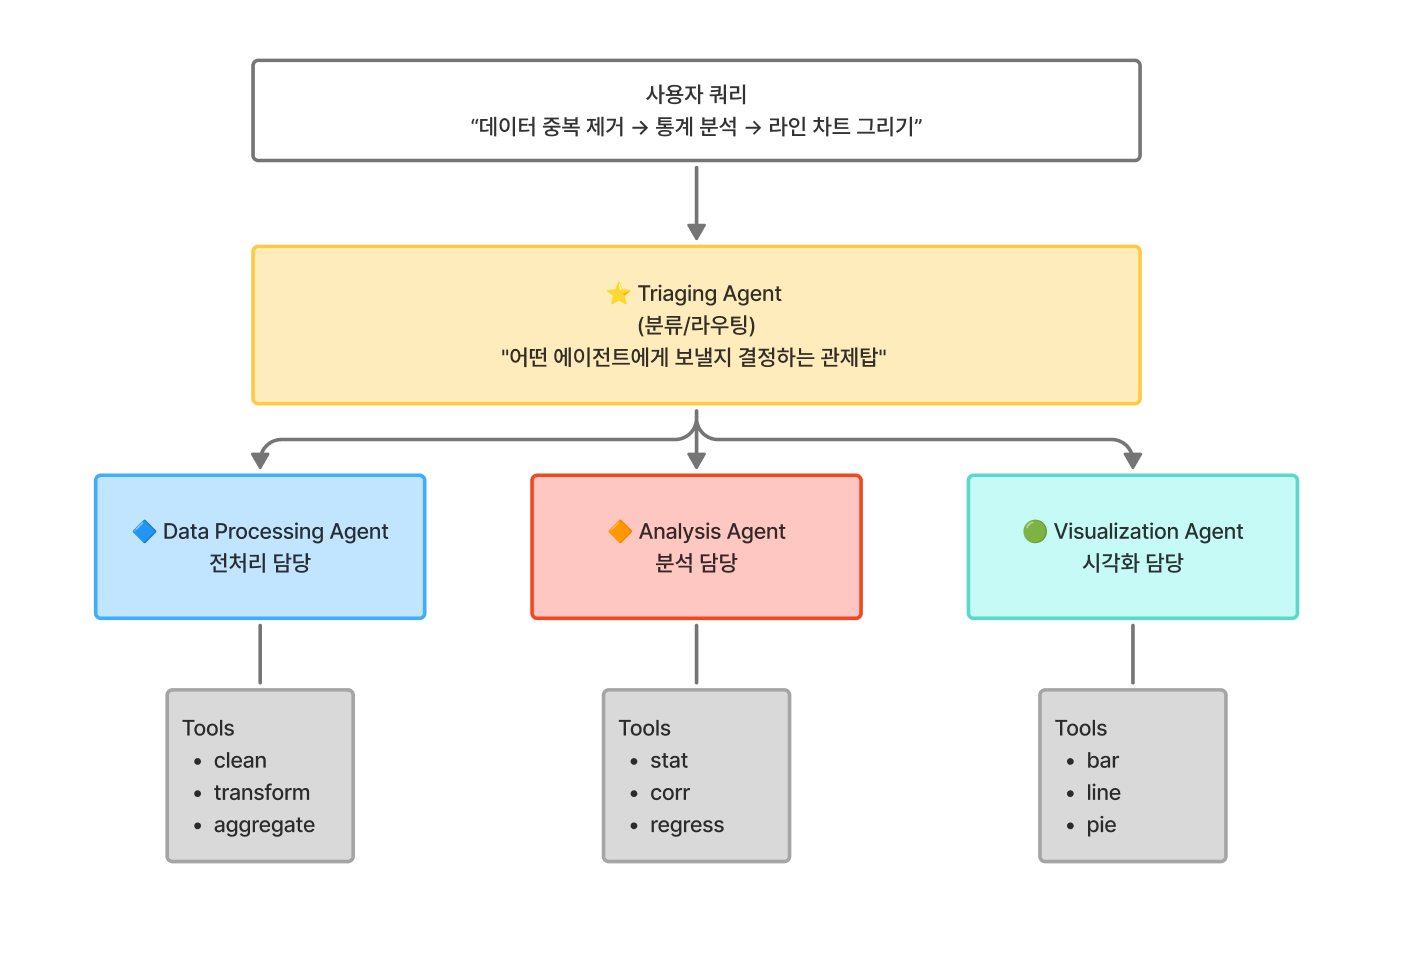



---
<font size="5">**핵심 컴포넌트**<font>

<font size="4">**1. Triaging Agent (관제탑)**<font>
**역할**: 사용자 쿼리 분석 및 적절한 에이전트로 라우팅

**기능**:
- 쿼리 의도 파악
- 작업 유형 분류
- 최적 에이전트 선택
- 작업 순서 조정 (파이프라인)

---

<font size="4">**2. 전문 에이전트들**<font>

<font size="3.5">**🔷 Data Processing Agent (데이터 전처리)**<font>
**목적**: 원본 데이터를 분석/시각화 가능한 형태로 변환

**주요 도구**:
- `clean`: 결측치 처리, 이상치 제거
- `transform`: 데이터 타입 변환, 정규화
- `aggregate`: 그룹화, 집계, 중복 제거

<font size="3.5">**🔶 Analysis Agent (통계 분석)**<font>
**목적**: 데이터에서 인사이트 추출

**주요 도구**:
- `stat`: 기술 통계 (평균, 중앙값, 표준편차 등)
- `corr`: 상관관계 분석
- `regress`: 회귀 분석, 예측 모델링

<font size="3.5">**#### 🟢 Visualization Agent (시각화)**<font>
**목적**: 분석 결과를 시각적으로 표현

**주요 도구**:
- `bar`: 막대 차트
- `line`: 라인 차트 (추세, 시계열)
- `pie`: 파이 차트 (비율, 구성)

---

<font size="5">**워크플로우 예시**<font>

<font size="4">**사용자 요청**<font>
> "데이터 중복 제거 → 통계 분석 → 라인 차트 그려줘"

<font size="4">**실행 순서**<font>
1. **Triaging Agent**: 3단계 파이프라인 식별
2. **Data Processing Agent**: `aggregate` 도구로 중복 제거
3. **Analysis Agent**: `stat` 도구로 통계 계산
4. **Visualization Agent**: `line` 도구로 차트 생성
```
사용자 쿼리
    ↓
Triaging Agent (분석 & 라우팅)
    ↓
Data Processing Agent (중복 제거)
    ↓
Analysis Agent (통계 분석)
    ↓
Visualization Agent (라인 차트)
    ↓
최종 결과
```

---

<font size="5">**장점**<font>
| 특징 | 설명 |
|------|------|
| **모듈성** | 각 에이전트가 독립적으로 작동 |
| **확장성** | 새로운 에이전트/도구 추가 용이 |
| **전문성** | 각 에이전트가 특정 도메인에 최적화 |
| **재사용성** | 에이전트 간 협업으로 복잡한 작업 처리 |

---

### ⚙️ **[ 실습 전 ] 데이터 분석 에이전트 실습 환경 설정**


---

**1. API Key 세팅 및 필요 모듈 가져오기**



In [ ]:
openai_api_key = load_openai_api_key()

# 환경변수 반영
os.environ.update(
    {
        "OPENAI_API_KEY": OPENAI_API_KEY,
    }
)

print("✅ API KEY 설정 완료")

In [ ]:
from openai import OpenAI
from IPython.display import Image, display
import json
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import numpy as np

# ==============================================
# 0. OpenAI 클라이언트 초기화 (추가)
# ==============================================
client = OpenAI()
MODEL = "gpt-4o-2024-08-06"

### 🔬 **[ 실습 ] Multi-Agent System 기반 데이터 분석 에이전트 실습**


---

**2. 프롬프트 세팅**

In [ ]:
# ==============================================
# 1. 시스템 프롬프트 정의
# ==============================================

triaging_system_prompt = """You are a Triaging Agent. Your role is to assess the user's query and route it to the relevant agents. The agents available are:
- Data Processing Agent: Cleans, transforms, and aggregates data.
- Analysis Agent: Performs statistical, correlation, and regression analysis.
- Visualization Agent: Creates bar charts, line charts, and pie charts.

Use the send_query_to_agents tool to forward the user's query to the relevant agents. Also, use the speak_to_user tool to get more information from the user if needed."""

processing_system_prompt = """You are a Data Processing Agent. Your role is to clean, transform, and aggregate data using the following tools:
- clean_data
- transform_data
- aggregate_data"""

analysis_system_prompt = """You are an Analysis Agent. Your role is to perform statistical, correlation, and regression analysis using the following tools:
- stat_analysis
- correlation_analysis
- regression_analysis"""

visualization_system_prompt = """You are a Professional Data Visualization Agent with expertise in creating stunning, publication-ready charts.

### Your Role
Transform raw data into visually compelling and insightful charts that tell a story.

### Design Principles
1. **Color Palette**: Use modern, harmonious color schemes (e.g., viridis, plasma, or custom gradients)
2. **Typography**: Clear, readable fonts with proper hierarchy
3. **Layout**: Clean composition with balanced white space
4. **Annotations**: Add context with titles, labels, and insights
5. **Style**: Professional, modern aesthetic suitable for presentations

### Available Tools
- create_bar_chart: For categorical comparisons (use gradient colors, rounded edges)
- create_line_chart: For trends over time (use smooth lines, markers, shaded areas)
- create_pie_chart: For proportions (use exploded slices, shadow effects)

### Chart Enhancement Guidelines
- Always include descriptive titles and axis labels
- Add gridlines with low opacity for readability
- Use color gradients or palettes instead of single colors
- Include legends when multiple series exist
- Add trend lines or annotations for key insights
- Apply subtle shadows or 3D effects where appropriate
"""

# ==============================================
# 2. 도구 정의
# ==============================================

triage_tools = [
    {
        "type": "function",
        "function": {
            "name": "send_query_to_agents",
            "description": "Sends the user query to relevant agents based on their capabilities.",
            "parameters": {
                "type": "object",
                "properties": {
                    "agents": {
                        "type": "array",
                        "items": {"type": "string"},
                        "description": "An array of agent names to send the query to."
                    },
                    "query": {
                        "type": "string",
                        "description": "The user query to send."
                    }
                },
                "required": ["agents", "query"],
                "additionalProperties": False  # strict 모드 필수
            }
        },
        "strict": True
    }
]

preprocess_tools = [
    {
        "type": "function",
        "function": {
            "name": "clean_data",
            "description": "Cleans the provided data by removing duplicates and handling missing values.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The dataset to clean. Should be in a suitable format such as JSON or CSV."
                    }
                },
                "required": ["data"],
                "additionalProperties": False
            }
        },
        "strict": True
    },
    {
        "type": "function",
        "function": {
            "name": "transform_data",
            "description": "Transforms data based on specified rules.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The data to transform. Should be in a suitable format such as JSON or CSV."
                    },
                    "rules": {
                        "type": "string",
                        "description": "Transformation rules to apply, specified in a structured format."
                    }
                },
                "required": ["data", "rules"],
                "additionalProperties": False
            }
        },
        "strict": True
    },
    {
        "type": "function",
        "function": {
            "name": "aggregate_data",
            "description": "Aggregates data by specified columns and operations.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The data to aggregate. Should be in a suitable format such as JSON or CSV."
                    },
                    "group_by": {
                        "type": "array",
                        "items": {"type": "string"},
                        "description": "Columns to group by."
                    },
                    "operations": {
                        "type": "string",
                        "description": "Aggregation operations to perform, specified in a structured format."
                    }
                },
                "required": ["data", "group_by", "operations"],
                "additionalProperties": False
            }
        },
        "strict": True
    }
]

analysis_tools = [
    {
        "type": "function",
        "function": {
            "name": "stat_analysis",
            "description": "Performs statistical analysis on the given dataset.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The dataset to analyze. Should be in a suitable format such as JSON or CSV."
                    }
                },
                "required": ["data"],
                "additionalProperties": False
            }
        },
        "strict": True
    },
    {
        "type": "function",
        "function": {
            "name": "correlation_analysis",
            "description": "Calculates correlation coefficients between variables in the dataset.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The dataset to analyze. Should be in a suitable format such as JSON or CSV."
                    },
                    "variables": {
                        "type": "array",
                        "items": {"type": "string"},
                        "description": "List of variables to calculate correlations for."
                    }
                },
                "required": ["data", "variables"],
                "additionalProperties": False
            }
        },
        "strict": True
    },
    {
        "type": "function",
        "function": {
            "name": "regression_analysis",
            "description": "Performs regression analysis on the dataset.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The dataset to analyze. Should be in a suitable format such as JSON or CSV."
                    },
                    "dependent_var": {
                        "type": "string",
                        "description": "The dependent variable for regression."
                    },
                    "independent_vars": {
                        "type": "array",
                        "items": {"type": "string"},
                        "description": "List of independent variables."
                    }
                },
                "required": ["data", "dependent_var", "independent_vars"],
                "additionalProperties": False
            }
        },
        "strict": True
    }
]

visualization_tools = [
    {
        "type": "function",
        "function": {
            "name": "create_bar_chart",
            "description": "Creates a bar chart from the provided data.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The data for the bar chart. Should be in a suitable format such as JSON or CSV."
                    },
                    "x": {
                        "type": "string",
                        "description": "Column for the x-axis."
                    },
                    "y": {
                        "type": "string",
                        "description": "Column for the y-axis."
                    }
                },
                "required": ["data", "x", "y"],
                "additionalProperties": False
            }
        },
        "strict": True
    },
    {
        "type": "function",
        "function": {
            "name": "create_line_chart",
            "description": "Creates a line chart from the provided data.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The data for the line chart. Should be in a suitable format such as JSON or CSV."
                    },
                    "x": {
                        "type": "string",
                        "description": "Column for the x-axis."
                    },
                    "y": {
                        "type": "string",
                        "description": "Column for the y-axis."
                    }
                },
                "required": ["data", "x", "y"],
                "additionalProperties": False
            }
        },
        "strict": True
    },
    {
        "type": "function",
        "function": {
            "name": "create_pie_chart",
            "description": "Creates a pie chart from the provided data.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The data for the pie chart. Should be in a suitable format such as JSON or CSV."
                    },
                    "labels": {
                        "type": "string",
                        "description": "Column for the labels."
                    },
                    "values": {
                        "type": "string",
                        "description": "Column for the values."
                    }
                },
                "required": ["data", "labels", "values"],
                "additionalProperties": False
            }
        },
        "strict": True
    }
]

**3. 실제 에이전트 로직**

In [ ]:

# ==============================================
# 3. 도구 실행 함수
# ==============================================

def clean_data(data):
    """데이터 정리: 중복 제거 및 결측치 처리"""
    data_io = StringIO(data)
    df = pd.read_csv(data_io, sep=",")
    df_cleaned = df.drop_duplicates()
    df_cleaned = df_cleaned.dropna()  # 결측치 제거 추가
    return df_cleaned

def stat_analysis(data):
    """통계 분석 수행"""
    data_io = StringIO(data)
    df = pd.read_csv(data_io, sep=",")
    return df.describe()

def plot_line_chart(data, x_col=None, y_col=None):
    """라인 차트 생성"""
    data_io = StringIO(data)
    df = pd.read_csv(data_io, sep=",")

    x = df.iloc[:, 0]
    y = df.iloc[:, 1]

    # 추세선 계산
    coefficients = np.polyfit(x, y, 1)
    polynomial = np.poly1d(coefficients)
    y_fit = polynomial(x)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'o', label='Data Points', markersize=10)
    plt.plot(x, y_fit, '-', label='Best Fit Line', linewidth=2)
    plt.title('Line Chart with Best Fit Line', fontsize=14)
    plt.xlabel(df.columns[0], fontsize=12)
    plt.ylabel(df.columns[1], fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==============================================
# 4. 도구 실행 핸들러
# ==============================================

def execute_tool(tool_calls, messages):
    """도구 호출 실행 및 결과 반환"""
    results = []

    for tool_call in tool_calls:
        tool_name = tool_call.function.name
        tool_arguments = json.loads(tool_call.function.arguments)
        tool_call_id = tool_call.id  # 중요: tool_call_id 추가

        result = None

        if tool_name == 'clean_data':
            cleaned_df = clean_data(tool_arguments['data'])
            result = {"cleaned_data": cleaned_df.to_csv(index=False)}
            print(f"\n{'='*50}")
            print("🧹 [Data Processing] 데이터 정리 완료")
            print(f"{'='*50}")
            print(cleaned_df)

        elif tool_name == 'transform_data':
            result = {"transformed_data": "sample_transformed_data"}
            print("\n🔄 [Data Processing] 데이터 변환 완료")

        elif tool_name == 'aggregate_data':
            result = {"aggregated_data": "sample_aggregated_data"}
            print("\n📊 [Data Processing] 데이터 집계 완료")

        elif tool_name == 'stat_analysis':
            stats_df = stat_analysis(tool_arguments['data'])
            result = {"stats": stats_df.to_dict()}
            print(f"\n{'='*50}")
            print("📈 [Analysis] 통계 분석 결과")
            print(f"{'='*50}")
            print(stats_df)

        elif tool_name == 'correlation_analysis':
            result = {"correlations": "sample_correlations"}
            print("\n🔗 [Analysis] 상관관계 분석 완료")

        elif tool_name == 'regression_analysis':
            result = {"regression_results": "sample_regression_results"}
            print("\n📉 [Analysis] 회귀 분석 완료")

        elif tool_name == 'create_bar_chart':
            result = {"bar_chart": "created"}
            print("\n📊 [Visualization] 막대 차트 생성 완료")

        elif tool_name == 'create_line_chart':
            result = {"line_chart": "created"}
            print(f"\n{'='*50}")
            print("📈 [Visualization] 라인 차트 생성")
            print(f"{'='*50}")
            plot_line_chart(tool_arguments['data'])

        elif tool_name == 'create_pie_chart':
            result = {"pie_chart": "created"}
            print("\n🥧 [Visualization] 파이 차트 생성 완료")

        # 메시지에 도구 결과 추가 (tool_call_id 포함)
        messages.append({
            "role": "tool",
            "tool_call_id": tool_call_id,  # 필수 필드
            "name": tool_name,
            "content": json.dumps(result)
        })
        results.append(result)

    return messages, results

# ==============================================
# 5. 에이전트 핸들러
# ==============================================

def handle_data_processing_agent(query, conversation_messages):
    """데이터 전처리 에이전트"""
    print("\n" + "🔷" * 20)
    print("🔷 Data Processing Agent 실행 중...")
    print("🔷" * 20)

    messages = [
        {"role": "system", "content": processing_system_prompt},
        {"role": "user", "content": query}
    ]

    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0,
        tools=preprocess_tools,
    )

    if response.choices[0].message.tool_calls:
        tool_calls_info = [
            {"name": tc.function.name, "args": tc.function.arguments}
            for tc in response.choices[0].message.tool_calls
        ]
        conversation_messages.append({"agent": "Data Processing", "tool_calls": tool_calls_info})
        execute_tool(response.choices[0].message.tool_calls, messages)

    return conversation_messages

def handle_analysis_agent(query, conversation_messages):
    """분석 에이전트"""
    print("\n" + "🔶" * 20)
    print("🔶 Analysis Agent 실행 중...")
    print("🔶" * 20)

    messages = [
        {"role": "system", "content": analysis_system_prompt},
        {"role": "user", "content": query}
    ]

    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0,
        tools=analysis_tools,
    )

    if response.choices[0].message.tool_calls:
        tool_calls_info = [
            {"name": tc.function.name, "args": tc.function.arguments}
            for tc in response.choices[0].message.tool_calls
        ]
        conversation_messages.append({"agent": "Analysis", "tool_calls": tool_calls_info})
        execute_tool(response.choices[0].message.tool_calls, messages)

    return conversation_messages

def handle_visualization_agent(query, conversation_messages):
    """시각화 에이전트"""
    print("\n" + "🟢" * 20)
    print("🟢 Visualization Agent 실행 중...")
    print("🟢" * 20)

    messages = [
        {"role": "system", "content": visualization_system_prompt},
        {"role": "user", "content": query}
    ]

    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0,
        tools=visualization_tools,
    )

    if response.choices[0].message.tool_calls:
        tool_calls_info = [
            {"name": tc.function.name, "args": tc.function.arguments}
            for tc in response.choices[0].message.tool_calls
        ]
        conversation_messages.append({"agent": "Visualization", "tool_calls": tool_calls_info})
        execute_tool(response.choices[0].message.tool_calls, messages)

    return conversation_messages

# ==============================================
# 6. 메인 핸들러
# ==============================================

def handle_user_message(user_query, conversation_messages=None):
    """사용자 메시지 처리 및 에이전트 라우팅"""

    if conversation_messages is None:
        conversation_messages = []

    print("=" * 60)
    print("🚀 멀티 에이전트 시스템 시작")
    print("=" * 60)
    print(f"\n📝 사용자 쿼리:\n{user_query}")

    user_message = {"role": "user", "content": user_query}
    conversation_messages.append(user_message)

    # Triaging Agent 호출
    messages = [
        {"role": "system", "content": triaging_system_prompt},
        {"role": "user", "content": user_query}
    ]

    print("\n" + "⭐" * 20)
    print("⭐ Triaging Agent 분석 중...")
    print("⭐" * 20)

    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0,
        tools=triage_tools,
    )

    # 도구 호출 처리
    if response.choices[0].message.tool_calls:
        for tool_call in response.choices[0].message.tool_calls:
            if tool_call.function.name == 'send_query_to_agents':
                arguments = json.loads(tool_call.function.arguments)
                agents = arguments['agents']
                query = arguments['query']

                print(f"\n📤 라우팅 대상 에이전트: {agents}")

                conversation_messages.append({
                    "triage_decision": {
                        "agents": agents,
                        "query": query
                    }
                })

                # 각 에이전트로 쿼리 전달
                for agent in agents:
                    if agent == "Data Processing Agent":
                        handle_data_processing_agent(query, conversation_messages)
                    elif agent == "Analysis Agent":
                        handle_analysis_agent(query, conversation_messages)
                    elif agent == "Visualization Agent":
                        handle_visualization_agent(query, conversation_messages)

    print("\n" + "=" * 60)
    print("✅ 모든 에이전트 작업 완료!")
    print("=" * 60)

    return conversation_messages

**4. 실행**

In [ ]:
# ==============================================
# 7. 실행
# ==============================================

user_query = """
Below is some data. I want you to first remove the duplicates then analyze
the statistics of the data. And last do the visualization for the best results.

house_size (m3), house_price ($)
90, 100
80, 90
100, 120
90, 100
"""

results = handle_user_message(user_query)

## 9️⃣ <font color="#FFA500">**9. 실습문제**</font>: MCP 기반 뉴스 검색 및 요약

> 📍 **학습 목표**
> - mcp 가 무엇인지 이해하고, 이를 어떻게 사용하는지 알기.
> - news api와 llm api를 이용한 mcp 서버를 활용하기.

### 🔌 [ 이론 ] MCP 란?

ChatGPT나 Claude 같은 LLM은 학습된 지식만 가지고 있습니다. 하지만 실제 서비스에서는 이런 외부 시스템과의 연동이 필요한 경우도 있습니다.

📰 최신 뉴스 검색 / 🗄️ 데이터베이스 조회 / 📧 이메일 전송 / 📁 파일 읽기/쓰기

이러한 서비스들은 주로 외부의 서버와 파이프라인에서 결과값을 가져와 프롬프트에 넣습니다. 하지만, 무분별하게 구현된다면 이들을 연동하는데 혼란스러울 것입니다.


**MCP(Model Context Protocol)**는 이런 문제를 해결하기 위한 Anthropic이 만든 표준 프로토콜로, LLM이 외부 도구와 통신할 수 있게 해줍니다.

***

이번 과정에서는 이런 MCP 프로토콜을 이용해 코렙에서 구동하여볼 것입니다.


MCP 서버는 기존에 만들어 두었던 서버를 이용합니다.
: https://github.com/Two-Jay/news_mcp_naver/blob/master/server.py

이 곳의 server.py 에서는 이미 FastMCP를 이용하여 구현된 서버가 있습니다.

### 🧭 [ 매뉴얼 ]. Naver 클라이언트 ID, SECRET 발급 방법

---



* 네이버 클라이언트 ID/SECRET은 MCP 내에서 검색 API를 활용하기 위해 필요합니다.
* 발급시에는 '네이버 계정'이 필요합니다.

***

1. 네이버에 로그인 한 뒤, [네이버 개발자 센터](https://developers.naver.com/main/)를 갑니다.

2. 네이버 개발자 센터 메인에서 상단 메뉴에 'Products' -> '서비스 API' -> '검색'을 찾아서 클릭합니다.

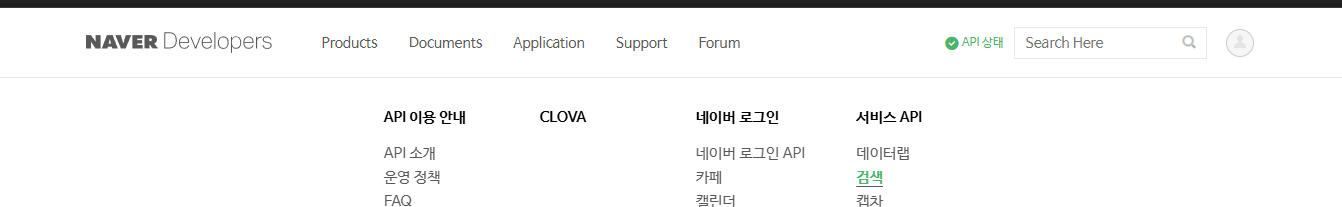

3. 페이지 하단의 오픈API 이용신청을 클릭합니다.

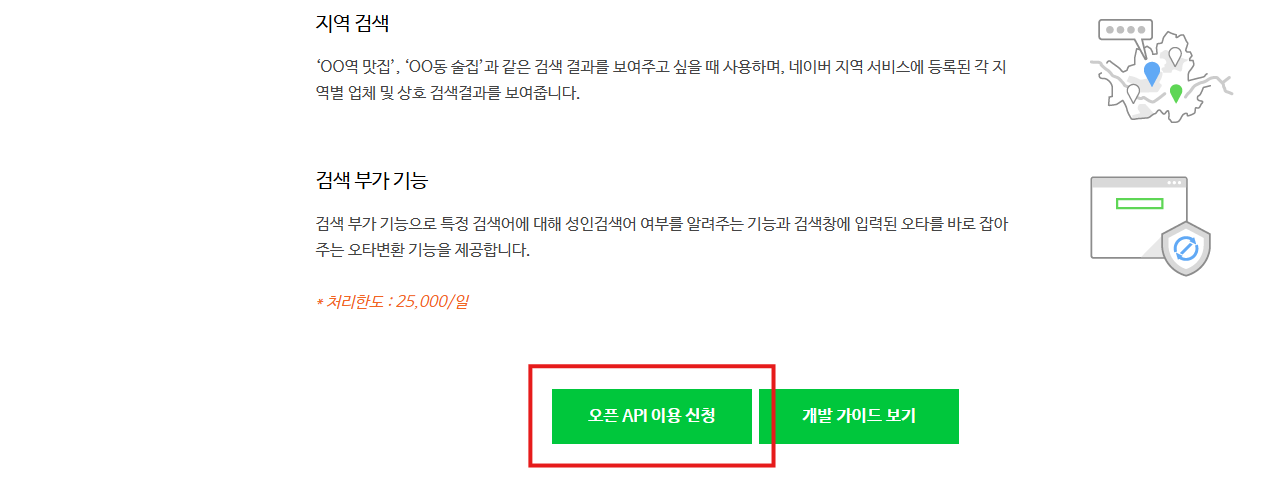

4. 기본적인 정보를 입력하세요.

* 애플리케이션 이름은 원하는대로 입력하시면 됩니다.
* 사용 API에서 '검색'은 선택이 되어야 합니다 (이후 MCP에서 뉴스 '검색' 활용하기 위함)
* '비로그인 오픈API 서비스환경' 에서는 '환경 추가'를 클릭하고, 'WEB설정'을 클릭하세요.


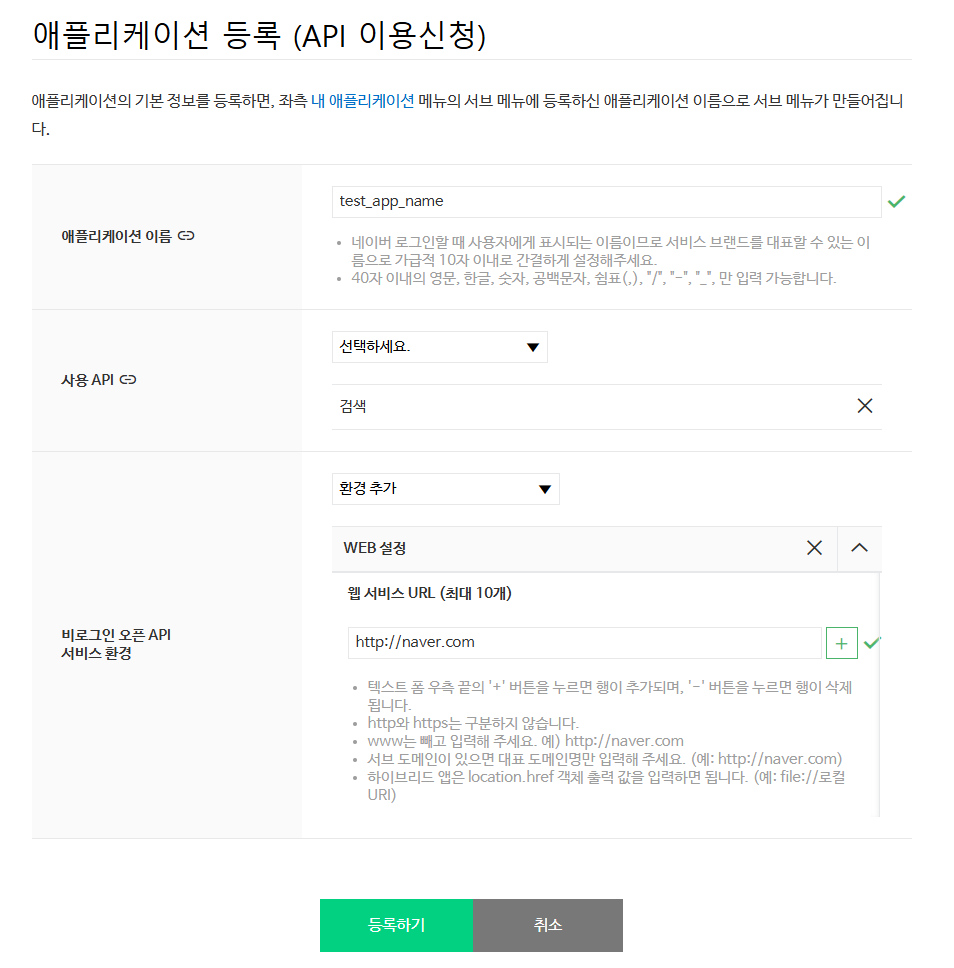

5. 발급된 클라이언트 ID와 SECRET을 모두 복사해서 활용하시면 됩니다.

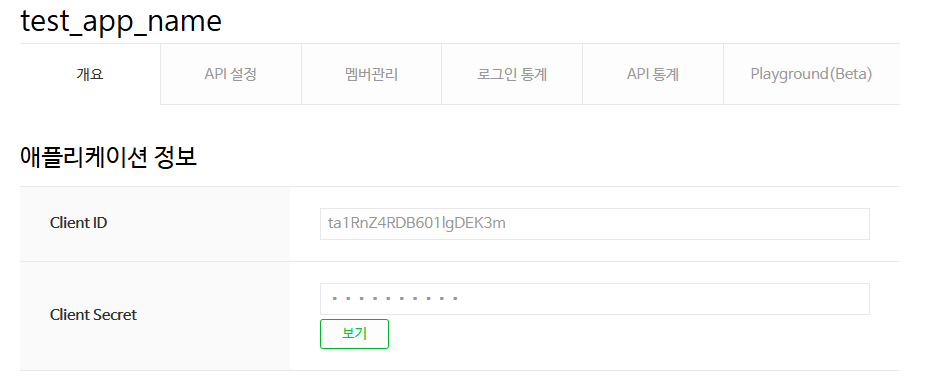

### ⚙️ **[ 실습 전 ] MCP 기반 뉴스 검색 및 요약 실습 환경 설정**


---

**1. 필요 모듈 및 MCP 서버 가져오기**

In [ ]:
# 레포 클론 & 패키지 설치
!rm -rf news_mcp_naver  # 기존 폴더 제거
!git clone https://github.com/Two-Jay/news_mcp_naver.git
!pip install -q anthropic aiohttp mcp httpx

In [ ]:
import sys
from google.colab import userdata

def load_openai_api_key() -> str:
    try:
        key = userdata.get("OPENAI_API_KEY")
    except userdata.SecretNotFoundError:
        raise RuntimeError(
            "Colab Secrets에 'OPENAI_API_KEY'가 등록되어 있지 않습니다.\n"
            "→ 좌측 🔑 아이콘에서 이름 'OPENAI_API_KEY'로 추가하세요."
        )
    except userdata.NotebookAccessError:
        raise RuntimeError(
            "이 노트북에 'OPENAI_API_KEY' 접근 권한이 꺼져 있습니다.\n"
            "→ 좌측 🔑 아이콘 → 해당 시크릿의 'Notebook access' 토글을 켜주세요."
        )
    except Exception as e:
        raise RuntimeError(f"Colab userdata 호출 실패: {type(e).__name__}: {e}")

    if key is None or not key.strip():
        raise RuntimeError("OPENAI_API_KEY 값이 비어 있습니다. Secrets에 등록된 값을 확인하세요.")

    key = key.strip()
    print(f"[OK] OPENAI_API_KEY 로드 완료 (length={len(key)})", file=sys.stderr)
    return key

In [ ]:
import sys
from typing import Tuple
from google.colab import userdata


def load_naver_api_credentials() -> Tuple[str, str]:
    """
    네이버 오픈 API 자격증명을 Colab Secrets에서 로드합니다.
    Returns:
        (NAVER_CLIENT_ID, NAVER_CLIENT_SECRET)
    """
    def _get(name: str) -> str:
        try:
            val = userdata.get(name)
        except userdata.SecretNotFoundError:
            raise RuntimeError(
                f"Colab Secrets에 '{name}'이(가) 등록되어 있지 않습니다.\n"
                f"→ 좌측 🔑 아이콘에서 이름 '{name}'(으)로 추가하세요."
            )
        except userdata.NotebookAccessError:
            raise RuntimeError(
                f"이 노트북에 '{name}' 접근 권한이 꺼져 있습니다.\n"
                f"→ 좌측 🔑 아이콘 → 해당 시크릿의 'Notebook access' 토글을 켜주세요."
            )
        except Exception as e:
            raise RuntimeError(f"Colab userdata 호출 실패({name}): {type(e).__name__}: {e}")

        if val is None or not val.strip():
            raise RuntimeError(f"{name} 값이 비어 있습니다. Secrets에 등록된 값을 확인하세요.")
        return val.strip()

    client_id = _get("NAVER_CLIENT_ID")
    client_secret = _get("NAVER_CLIENT_SECRET")

    print(
        f"[OK] NAVER 자격증명 로드 완료 "
        f"(client_id_len={len(client_id)}, client_secret_len={len(client_secret)})",
        file=sys.stderr,
    )
    return client_id, client_secret

In [ ]:
import os

openai_apikey = load_openai_api_key()
naver_id, naver_secret = load_naver_api_credentials()

os.environ.update({
    "OPENAI_API_KEY":   openai_apikey,
    "NAVER_CLIENT_ID":     naver_id,
    "NAVER_CLIENT_SECRET": naver_secret,
})

### ⚙️ **[ 실습 ] MCP 기반 뉴스 검색 및 요약 실습**


---



**2. MCP 사용해보기**

MCP는 기본적으로 클라이언트-서버 구조의 프로토콜로, 서로 간의 통신에서 정해진 양식에 불과하지만, Anthropic은 이를 따로 구현하여 간편하게 MCP 서버를 구현할 수 있는 모듈로 만들었습니다.

따라서 Claude for Desktop과 같은 플랫폼에서도 활용할 수 있으며, 여러분의 클라이언트에서도 이를 활용할 수 있습니다. 이 경우 보통은 Tool의 형태로 mcp 서버를 활용하고, 이를 이용합니다.


***

이번 시간에서는 아래와 같이 MCP 클라이언트를 구현하고, 기존에 준비된 서버를 별도의 프로세스에서 실행한 뒤, 서로 통신하여 응답을 Claude api에 반영할 것입니다.


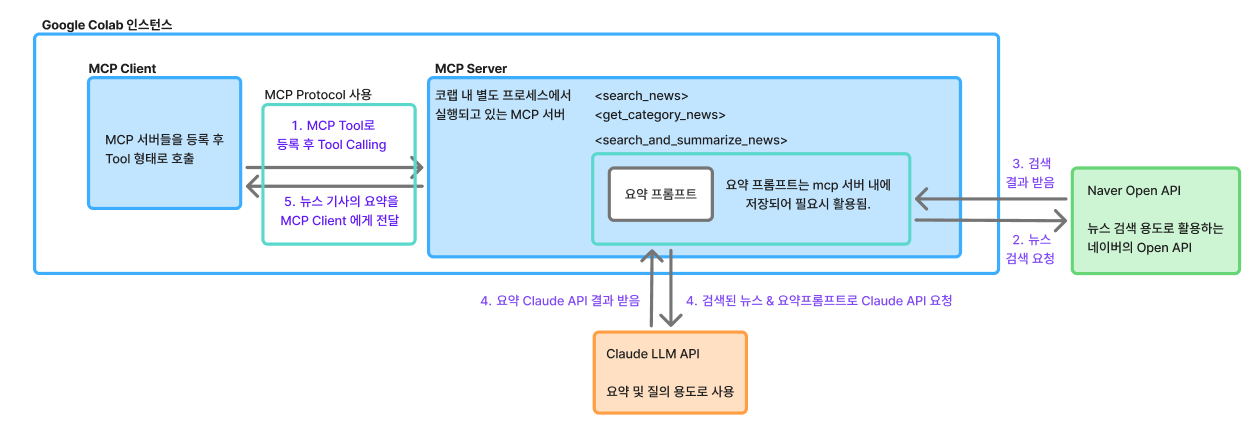

**3. MCP Client 정의**

In [ ]:
import asyncio
import json
import sys
from typing import Optional, Dict, Any, List

# 서버 경로 설정 (news_mcp_naver 레포지토리 구조에 맞게 설정)
# 일반적인 경로들 - 실제 레포 구조에 맞게 조정 필요
SERVER_PATH = "news_mcp_naver/src/news_mcp_naver/server.py"

# 설정
DEFAULT_TIMEOUT = 30  # 초
INIT_TIMEOUT = 15     # 초기화 타임아웃


class MCPClient:
    """
    Colab 호환 MCP 클라이언트 (v7)

    FastMCP 기본 모드: 줄 단위 JSON (newline-delimited JSON)
    - Content-Length 헤더 없음
    - 각 JSON 메시지는 한 줄로 전송
    - 줄바꿈(\n)으로 메시지 구분
    """

    def __init__(self, server_command: str, server_args: List[str], verbose: bool = True):
        self.server_command = server_command
        self.server_args = server_args
        self.process: Optional[asyncio.subprocess.Process] = None
        self.request_id = 0
        self._lock = asyncio.Lock()
        self.verbose = verbose
        self._stderr_task: Optional[asyncio.Task] = None
        self._stderr_lines: List[str] = []

    async def _read_stderr(self):
        """stderr를 백그라운드에서 비동기로 읽기"""
        try:
            while self.process and self.process.stderr:
                line = await self.process.stderr.readline()
                if not line:
                    break
                decoded = line.decode().strip()
                if decoded:
                    self._stderr_lines.append(decoded)
                    if self.verbose:
                        print(f"  [stderr] {decoded}", file=sys.stderr)
        except asyncio.CancelledError:
            pass
        except Exception as e:
            if self.verbose:
                print(f"  [stderr reader error] {e}", file=sys.stderr)

    async def start(self, timeout: float = INIT_TIMEOUT):
        """MCP 서버 시작 및 초기화"""
        if self.verbose:
            print(f"🚀 서버 시작 중: {self.server_command} {' '.join(self.server_args)}")

        # 환경 변수를 subprocess에 전달
        env = os.environ.copy()

        self.process = await asyncio.create_subprocess_exec(
            self.server_command,
            *self.server_args,
            stdin=asyncio.subprocess.PIPE,
            stdout=asyncio.subprocess.PIPE,
            stderr=asyncio.subprocess.PIPE,
            env=env
        )

        # stderr 백그라운드 읽기 시작
        self._stderr_task = asyncio.create_task(self._read_stderr())

        # 서버가 바로 죽었는지 확인
        await asyncio.sleep(0.3)
        if self.process.returncode is not None:
            stderr_output = "\n".join(self._stderr_lines)
            raise RuntimeError(f"서버가 즉시 종료됨 (code={self.process.returncode})\n{stderr_output}")

        if self.verbose:
            print(f"   PID: {self.process.pid}")

        # MCP 초기화 핸드셰이크
        try:
            init_result = await asyncio.wait_for(
                self._send_request("initialize", {
                    "protocolVersion": "2024-11-05",
                    "capabilities": {},
                    "clientInfo": {
                        "name": "colab-mcp-client",
                        "version": "1.0.0"
                    }
                }),
                timeout=timeout
            )
        except asyncio.TimeoutError:
            stderr_output = "\n".join(self._stderr_lines[-10:])
            await self.stop()
            raise TimeoutError(f"초기화 타임아웃 ({timeout}s)\n최근 stderr:\n{stderr_output}")

        # initialized 알림 전송
        await self._send_notification("notifications/initialized", {})

        if self.verbose:
            print(f"✅ MCP 서버 시작됨 (protocol: {init_result.get('protocolVersion', 'unknown')})")
        return init_result

    async def stop(self):
        """MCP 서버 종료"""
        if self._stderr_task:
            self._stderr_task.cancel()
            try:
                await self._stderr_task
            except asyncio.CancelledError:
                pass
            self._stderr_task = None

        if self.process:
            self.process.terminate()
            try:
                await asyncio.wait_for(self.process.wait(), timeout=5)
            except asyncio.TimeoutError:
                self.process.kill()
                await self.process.wait()
            self.process = None
            if self.verbose:
                print("✅ MCP 서버 종료됨")

    def _check_process(self):
        """프로세스 상태 확인"""
        if not self.process:
            raise RuntimeError("서버가 시작되지 않았습니다")
        if self.process.returncode is not None:
            stderr_output = "\n".join(self._stderr_lines[-10:])
            raise RuntimeError(f"서버가 종료됨 (code={self.process.returncode})\n{stderr_output}")

    async def _send_request(self, method: str, params: Dict[str, Any], timeout: float = DEFAULT_TIMEOUT) -> Dict[str, Any]:
        """JSON-RPC 요청 전송 및 응답 수신"""
        async with self._lock:
            self._check_process()

            self.request_id += 1
            request = {
                "jsonrpc": "2.0",
                "id": self.request_id,
                "method": method,
                "params": params
            }

            if self.verbose:
                print(f"   → [{self.request_id}] {method}")

            await self._write_message(request)

            try:
                response = await asyncio.wait_for(
                    self._read_message(),
                    timeout=timeout
                )
            except asyncio.TimeoutError:
                raise TimeoutError(f"{method} 응답 타임아웃 ({timeout}s)")

            if "error" in response:
                raise Exception(f"MCP Error: {response['error']}")

            return response.get("result", {})

    async def _send_notification(self, method: str, params: Dict[str, Any]):
        """JSON-RPC 알림 전송 (응답 없음)"""
        self._check_process()

        notification = {
            "jsonrpc": "2.0",
            "method": method,
            "params": params
        }
        await self._write_message(notification)

    async def _write_message(self, message: Dict[str, Any]):
        """
        줄 단위 JSON 형식으로 메시지 전송 (FastMCP 기본 모드)
        - Content-Length 헤더 없음
        - JSON을 한 줄로 직렬화 후 줄바꿈 추가
        """
        # JSON을 한 줄로 (줄바꿈 없이) 직렬화
        json_line = json.dumps(message, separators=(',', ':')) + "\n"

        self.process.stdin.write(json_line.encode('utf-8'))
        await self.process.stdin.drain()

    async def _read_message(self) -> Dict[str, Any]:
        """
        줄 단위 JSON 형식으로 메시지 수신
        - 한 줄씩 읽어서 JSON 파싱
        """
        while True:
            self._check_process()

            line = await self.process.stdout.readline()
            if not line:
                raise RuntimeError("서버 연결 끊김 (EOF)")

            line_str = line.decode('utf-8').strip()

            # 빈 줄 무시
            if not line_str:
                continue

            try:
                return json.loads(line_str)
            except json.JSONDecodeError as e:
                # JSON이 아닌 줄은 로깅하고 계속
                if self.verbose:
                    print(f"   [non-json stdout] {line_str[:100]}")
                continue

    async def list_tools(self, timeout: float = DEFAULT_TIMEOUT) -> List[Dict[str, Any]]:
        """사용 가능한 도구 목록 조회"""
        result = await self._send_request("tools/list", {}, timeout=timeout)
        return result.get("tools", [])

    async def call_tool(self, name: str, arguments: Dict[str, Any], timeout: float = DEFAULT_TIMEOUT) -> str:
        """도구 호출"""
        result = await self._send_request("tools/call", {
            "name": name,
            "arguments": arguments
        }, timeout=timeout)

        # content 배열에서 텍스트 추출
        content = result.get("content", [])
        texts = [item.get("text", "") for item in content if item.get("type") == "text"]
        return "\n".join(texts)

    def get_stderr_log(self) -> str:
        """수집된 stderr 로그 반환"""
        return "\n".join(self._stderr_lines)


print("✅ MCPClient 클래스 정의 완료")

**4. 대화 인터페이스 정의**

In [ ]:
OPENAI_MODEL = "gpt-5.4-nano"
SYSTEM_PROMPT = (
    "네이버 뉴스 검색 어시스턴트입니다. "
    "도구를 활용하여 최신 뉴스를 검색하고 분석하세요. 한국어로 응답하세요."
)
MAX_OUTPUT_TOKENS = 8192      # reasoning + visible 합산이라 넉넉하게 설정
REASONING_EFFORT = "low"
VERBOSITY = "medium"
MAX_ITERATIONS = 10

In [ ]:
def mcp_tool_to_openai_tool(tool: dict) -> dict:
    """MCP 도구를 Responses API의 flat function 포맷으로 변환."""
    return {
        "type": "function",
        "name": tool["name"],
        "description": tool.get("description", ""),
        "parameters": tool.get("inputSchema") or {
            "type": "object",
            "properties": {},
        },
    }

In [ ]:
import json
from openai import OpenAI


async def chat_async(user_message: str, verbose: bool = True, tool_timeout: float = 60) -> str:
    """MCP 서버 + OpenAI Responses API 연동 대화."""
    print(f"🔍 질문: {user_message}\n")
    print("=" * 60)

    mcp = MCPClient("python", [SERVER_PATH], verbose=verbose)

    try:
        await mcp.start()
    except Exception as e:
        print(f"❌ 서버 시작 실패: {e}")
        print(f"\n📋 stderr 로그:\n{mcp.get_stderr_log()}")
        return ""

    try:
        tools = await mcp.list_tools()
        if verbose:
            print(f"\n📦 도구 {len(tools)}개: {[t['name'] for t in tools]}\n")

        openai_tools = [mcp_tool_to_openai_tool(t) for t in tools]

        client = OpenAI(api_key=openai_apikey)

        # 첫 턴 입력
        input_items = [{"role": "user", "content": user_message}]
        previous_response_id = None

        iteration = 0
        while iteration < MAX_ITERATIONS:
            iteration += 1

            kwargs = {
                "model": OPENAI_MODEL,
                "instructions": SYSTEM_PROMPT,
                "input": input_items,
                "tools": openai_tools if openai_tools else None,
                "max_output_tokens": MAX_OUTPUT_TOKENS,
                "reasoning": {"effort": REASONING_EFFORT},
                "text": {"verbosity": VERBOSITY},
            }
            if previous_response_id:
                kwargs["previous_response_id"] = previous_response_id

            response = client.responses.create(**kwargs)
            previous_response_id = response.id

            if verbose:
                print(f"   [iter {iteration}] status: {response.status}")

            # output 안에서 function_call 아이템만 추출
            function_calls = [
                item for item in response.output
                if getattr(item, "type", None) == "function_call"
            ]

            # 도구 호출 없음 → 종료
            if not function_calls:
                final_text = response.output_text or ""
                print(f"\n🤖 응답:\n{final_text}")
                return final_text

            # 도구 호출 실행 → function_call_output 으로 다음 턴에 전달
            new_input_items = []
            for fc in function_calls:
                tool_name = fc.name
                try:
                    tool_input = json.loads(fc.arguments or "{}")
                except json.JSONDecodeError:
                    tool_input = {}

                if verbose:
                    preview = json.dumps(tool_input, ensure_ascii=False)[:100]
                    print(f"\n🔧 {tool_name}: {preview}")

                try:
                    result_text = await mcp.call_tool(tool_name, tool_input, timeout=tool_timeout)
                    if verbose:
                        print(f"   ✓ 결과: {str(result_text)[:200]}...")
                except TimeoutError as e:
                    result_text = f"타임아웃 오류: {e}"
                    if verbose:
                        print(f"   ✗ {result_text}")
                except Exception as e:
                    result_text = f"오류: {e}"
                    if verbose:
                        print(f"   ✗ {result_text}")

                new_input_items.append({
                    "type": "function_call_output",
                    "call_id": fc.call_id,
                    "output": str(result_text),
                })

            # previous_response_id로 이어가므로 새 도구 출력만 input으로 보냄
            input_items = new_input_items

        print(f"⚠️ 최대 반복 횟수({MAX_ITERATIONS}) 도달")

    except Exception as e:
        print(f"\n❌ 오류 발생: {e}")
        print(f"\n📋 stderr 로그:\n{mcp.get_stderr_log()}")
        raise

    finally:
        await mcp.stop()

    return ""


print("✅ chat_async() 함수 준비 완료 (Responses API 버전)")

**5. MCP 서버 파일 체크**

In [ ]:
# 서버 파일 경로 확인
import os

print("📂 news_mcp_naver 레포지토리 구조 확인:\n")

# 가능한 서버 경로들
possible_paths = [
    "news_mcp_naver/src/news_mcp_naver/server.py",
    "news_mcp_naver/server.py",
    "news_mcp_naver/src/server.py",
    "news_mcp_naver/main.py",
]

found_path = None
for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ 발견: {path}")
        found_path = path
        break
    else:
        print(f"   ❌ {path}")

if found_path:
    SERVER_PATH = found_path
    print(f"\n🎯 SERVER_PATH = \"{SERVER_PATH}\"")
else:
    print("\n⚠️ 서버 파일을 찾지 못했습니다. 디렉토리 구조를 확인합니다...")
    !find news_mcp_naver -name "*.py" -type f | head -20

**6. 테스트 및 실행**

이제 서버를 켜보고, 도구를 잘 가져올 수 있는 지 확인합니다.

mcp 모듈의 함수들을 이용해. 서버를 열고, 연결을 해본 뒤 그 결과를 가져오는 테스트코드가 아래에 있습니다.

In [ ]:
# 서버 연결 테스트
async def test_server_connection():
    print("🧪 서버 연결 테스트 (줄 단위 JSON)...\n")

    mcp = MCPClient("python", [SERVER_PATH], verbose=True)

    try:
        init_result = await mcp.start(timeout=15)
        print(f"\n✅ 초기화 성공!")
        print(f"   서버 정보: {json.dumps(init_result, indent=2, ensure_ascii=False)}")

        tools = await mcp.list_tools()
        print(f"\n📦 사용 가능한 도구 ({len(tools)}개):")
        for t in tools:
            print(f"   - {t['name']}: {t.get('description', '')[:60]}...")

        return True

    except Exception as e:
        print(f"\n❌ 테스트 실패: {e}")
        print(f"\n📋 stderr 로그:\n{mcp.get_stderr_log()}")
        return False

    finally:
        await mcp.stop()

await test_server_connection()

In [ ]:
# 도구 호출 테스트 (네이버 뉴스 검색)
async def test_tool_call():
    print("🧪 도구 호출 테스트...\n")

    mcp = MCPClient("python", [SERVER_PATH], verbose=True)

    try:
        await mcp.start()

        # 사용 가능한 도구 목록 먼저 확인
        tools = await mcp.list_tools()
        print(f"\n📦 사용 가능한 도구: {[t['name'] for t in tools]}")

        if not tools:
            print("⚠️ 사용 가능한 도구가 없습니다.")
            return False

        # 첫 번째 도구로 테스트 (보통 search_news 같은 이름일 것)
        first_tool = tools[0]
        tool_name = first_tool['name']

        print(f"\n🔧 {tool_name} 호출 중...")

        # 도구 스키마 확인
        input_schema = first_tool.get('inputSchema', {})
        print(f"   입력 스키마: {json.dumps(input_schema, indent=2, ensure_ascii=False)[:300]}")

        # 일반적인 뉴스 검색 파라미터 시도
        test_params = {
            "query": "인공지능",
        }

        result = await mcp.call_tool(tool_name, test_params, timeout=30)
        print(f"\n✅ 결과:\n{result}...")
        return True

    except Exception as e:
        print(f"\n❌ 테스트 실패: {e}")
        print(f"\n📋 stderr 로그:\n{mcp.get_stderr_log()}")
        return False

    finally:
        await mcp.stop()

await test_tool_call()

테스트가 끝났다면, 이제 구현된 함수를 이용해서 MCP Client에 요청을 넣어봅니다.

잘 동작한다면, Client는 Tool의 형태로 MCP Server의 기능을 호출하고, 이를 활용합니다.

In [ ]:
await chat_async("삼성전자 주가 관련 뉴스를 요약해줘", verbose=True)

In [ ]:
await chat_async("CES 2026 관련 뉴스를 요약해줘", verbose=True)